# 3. 图形绘制

- 图形绘制的功能都是由Axes对象提供，pyplot做了二次封装，提供了更加强大的图像绘制封装。pyplot提供的图形绘制功能有如下分类：
    - 基本图元
    - 分隔线与块
    - 频谱图
    - 统计图
    - 分箱图
    - 轮廓图
    - 2D数组图（包含图像）
    - 非结构化三角形
    - 文本与标注
    - 向量场

- 图形绘制的核心是理解数据，构建合适格式的数据，对数据有充分的理解，才能选择最合适的图形进行绘制。同时绘制过程对图形的样式属性进行合理的设置，我们对绘制函数讲解两个个重点：
    - 图形的数据构建与输出认知。
    - 图形的样式属性。

- 其中各种图元的数据，我们采用两种方式：
    - 使用numpy的功能构建虚拟数据（这里需要对numpy能熟练的使用）。
    - 使用企业、互联网、标准数据集等多种来源的数据。

## 3.1. 基本图元

### (1) 曲线绘制-plot

- 条形图绘制函数是plot，这是非常常用的绘制功能，其原型定义如下：
    - `matplotlib.pyplot.plot(*args, scalex=True, scaley=True, data=None, **kwargs)`
        - 其中`*args`参数是省略的写法，实际包含很多。
            - x, y：用来指定绘制曲线的数据，类型是float或者数组。曲线都是由若干点构成，(x，y)就代表曲线上的所有点（也可以是一个点）。
            - fmt：格式字符串，用来设置曲线上每个点的输出样式，也是线条的输出样式，包括颜色与线段样式
        - data：被标签的数据对象，提供具有标签的x，y数据。
        - scalex, scaley：参数是逻辑值，用来确定坐标轴的刻度根据数据自动调整。默认是True。
        - `**kwargs`参数用来指定曲线绘制的属性，属性比较多、且复杂。
        - 函数返回Line2D对象。

- `matplotlib.pyplot.plot`函数实际是Axes对象plot函数的二次封装。

- x，y参数说明（结合下面代码理解）：
    - 如果是float小数，则绘制点。
    - 如果是两个数组，则绘制曲线（含线段折线）。
    - 注意：x, y参数是`*args`参数的一部分，只能使用位置参数，不是关键字参数。换句话说，`*args`参数是边长参数，只能是一个数值列表。参数不能这样使用:`plot(x=20, y=20)`

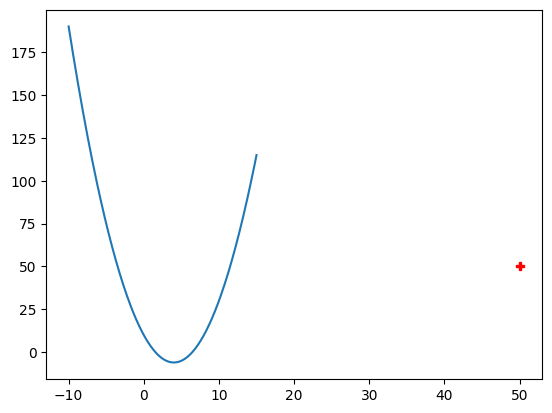

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x1 = 50
y1 = 50

# 绘制一个点
plt.plot(x1, y1, "rP", scalex=True)  # r表示红色，o表示原点
# plt.plot(x=x1, y=y1) # 这样是错的，因为没有x，y参数，只有*args变长参数

x2 = np.linspace(-10, 15, 200)  
y2 =x2 * x2 - 8*x2 + 10   # 二次曲线（抛物线）
plt.plot(x2, y2, scalex=True)


- 代码说明：
    - 为了看见点，我们使用了fmt参数`ro`，该格式下面专门介绍，其中`r`表示Red红色，`o`表示圆点。
    - `scalex=True`说明坐标轴长短根据绘制数据x,y自动放大缩小调整，没有指定坐标轴长短（limits）的时候，默认是`[0,1]`区间。如果`scalex=False`，则图形的数据超过这个区间，则绘制的图形会被截取，输出会不可见。我们建议设置为`scalex`设置为True，这样我们可以确保可以看见完整的输出。

- fmt参数说明：
    - fmt参数是字符串在matplotlib中有专门的规则，可以使用多个字符参数指定，也可以使用字符串指定，因为是边长参数，所以x，y与fmt的边界容易歧义。因为使用data的时候，`*args`参数中可以没有x，y数据，这个时候就容易歧义，运行会报警告，消除警告的官方解决方案是，在fmt参数结束采用空字符``来消除。
    - fmt一般由如下样式组成：
        - `fmt = '[marker][line][color]'`: `[标记][线段样式][颜色]`，顺序可以忽略, 每个部分可选

- fmt参数可以使用marker标记定义：

|字符|含义描述|
|---|--------|
|'.'|点|
|','|像素|
|'o'|圆|
|'v'|下三角|
|'^'|上三角|
|'<'|左三角|
|'>'|右三角|
|'1'|下三段线|
|'2'|上三段线|
|'3'|左三段线|
|'4'|右三段线|
|'8'|八边形|
|'s'|正方形|
|'p'|五边形|
|'P'|加号(实心，粗)|
|'*'|星号|
|'h'|六边形(上面是角)|
|'H'|六边形(上面是线段,是h旋转90度的效果)|
|'+'|加号（细）|
|'x'|乘号|
|'X'|乘号（实心，粗）|
|'D'|菱形|
|'d'|菱形（细）|
|'|'|垂直线|
|'_'|水平线|

- fmt参数可以使用的line样式定义:

|字符|含义描述|
|---|--------|
|'-'|实线|
|'--'|虚线|
|'-.'|点划线|
|':'|点线|

- fmt参数可以使用的coloe颜色定义:

|字符|含义描述|
|---|--------|
|'b'|blue蓝色|
|'g'|green绿色|
|'r'|red红色|
|'c'|cyan青色|
|'m'|magenta品红|
|'y'|yellow黄色|
|'k'|balck黑色|
|'w'|white白色|

- 因为plot是通过点之间连线构成，marker决定点的样式，lines决定连线的样式。如果上面的颜色单独作为参数，可以使用matplotlib的颜色格式，比如全称`green`或者16进制表示`#008000`

- marker的例子

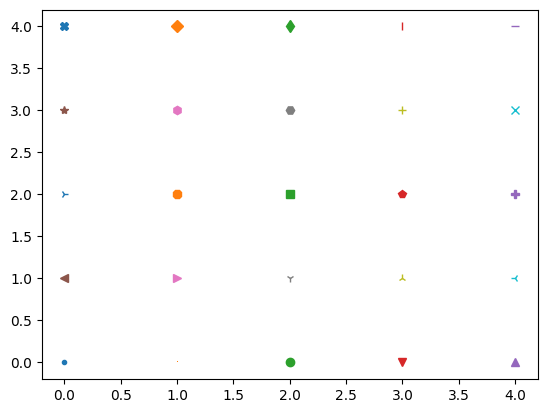

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

markers = np.array([
    ['.', ',', 'o', 'v', '^'],
    ['<', '>', '1', '2', '3'], 
    ['4', '8', 's', 'p', 'P'], 
    ['*', 'h', 'H', '+', 'x'], 
    ['X', 'D', 'd', '|', '_']
])

row, col = markers.shape
for y in range(row):
    for x in range(col):
        plt.plot(x, y, markers[y, x])

plt.show() # 在交互模式下，该函数不需调用

- 代码说明：
    - 我们把所有markers保存在一个二维数组，然后按照5行5列输出。
    - 上面绘制的时候，默认采用随机不同的颜色。

- fmt的使用方式例子

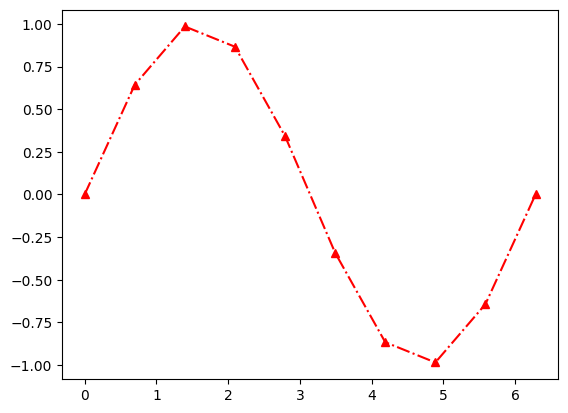

In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 10)
y = np.sin(x)

plt.plot(x, y, 'r-.^')  # 不讲究顺序


- data参数说明：
    - data参数是matplotlib为了提高与pandas等数据分析库的兼容性而引入的功能，在处理结构化数据时能显著简化代码并提高可读性。
    - data参数作用与x，y一样也可以指定曲线绘制的数据，使用data参数的场景主要是一些结构化数据，尤其已经生成的字典数据或者pandas的DataFrame等数据集。
    - data参数可以使用表格结构化数据，使用标签作为表格的字段（或者列），在x,y参数位置就可以使用data中的字段来使用data中的数据，下面使用代码例子说明。

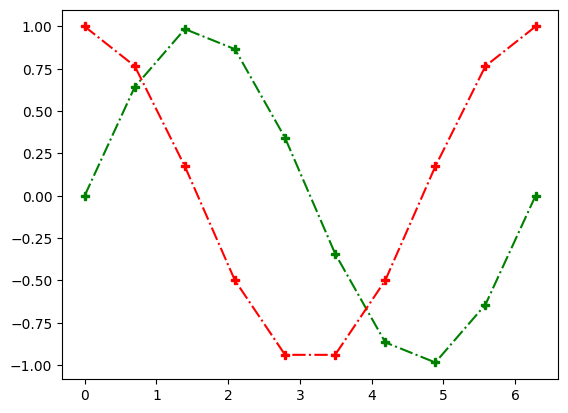

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 生成样本数据
np.random.seed(42)
x_data = np.linspace(0, 2*np.pi, 10)
y_data1 = np.sin(x_data)
y_data2 = np.cos(x_data)

data = {
    "x_data": x_data,
    "y_data1": y_data1,
    "y_data2": y_data2
}

# 使用pandas中的DataFrame也是一样的（支持结构化数据，支持字典key访问的结构化数据都行）
import pandas as pd
df = pd.DataFrame(data)

plt.plot("x_data", "y_data1", "P-.g", data=data) # 使用dict结构数据
plt.plot("x_data", "y_data2", "P-.r", data=df)   # 使用DataFrame结构数据


- 代码说明：
    - data参数适用场景（这种数据在企业中常见）：
        - 当数据已经组织在字典、DataFrame等结构中时（来自数据库或者Excel表格的结构化数据）
        - 需要提高代码可读性时
        - 处理包含列名的结构化数据时
    - x, y参数适用场景：
        - 数据已经是numpy数组或列表时
        - 需要绘制计算得到的数据（如拟合曲线）时
        - 处理简单或非结构化数据时
    - 注意事项：
        - 使用data参数时，x和y参数应传递字符串（列名）
        - 不是所有matplotlib函数都支持data参数
        - 混合使用data参数和直接数据时要注意一致性（不建议混合使用），如下就是混合使用：
            - `plt.plot(x_data, "y_data1", "P-.g", data=data)`

- `**kwargs`参数说明：
    - `**kwargs`参数用来指定所有Line2D中具有的属性。在Line2D的主题中专门介绍，这里使用几个例子说明用途即可，我们依然使用上面的例子来修改。

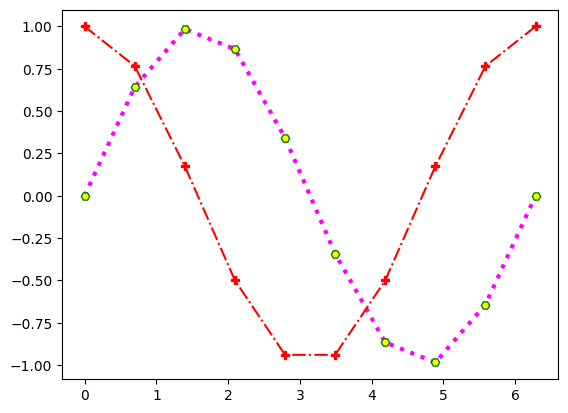

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# 生成样本数据
np.random.seed(42)
x_data = np.linspace(0, 2*np.pi, 10)
y_data1 = np.sin(x_data)
y_data2 = np.cos(x_data)

data = {
    "x_data": x_data,
    "y_data1": y_data1,
    "y_data2": y_data2
}

# 使用pandas中的DataFrame也是一样的（支持结构化数据，支持字典key访问的结构化数据都行）
import pandas as pd
df = pd.DataFrame(data)

plt.plot(x_data, "y_data1", data=data, 
         linewidth=3, 
         marker="H", 
         color="#FF00FF", 
         linestyle=":", 
         markeredgecolor="green",
         markerfacecolor="yellow"
) # 混合使用x_data与data中x_data列
plt.plot("x_data", "y_data2", "P-.r", data=df)   # 使用DataFrame结构数据


- 代码说明：
    - 使用Line2D的属性对曲线样式可以进行更加精确的设置，当然也要复杂得多。我们在上面代码中使用了Line2D的如下属性：
        - `linewidth=3`：连线的宽度
        - `marker="H"`：标记的样式
        - `color="#FF00FF"`：线条的颜色，使用的是16进制表示颜色FF(红色分量)00(绿色分量)FF(蓝色分量) 
        - `linestyle=":"`：连线的样式
        - `markeredgecolor="green"`：标记的边界颜色
        - `markerfacecolor="yellow"`：标记的填充颜色

### (2) 散点图绘制-scatter

- pyplot模块中使用scatter函数绘制散点图，该函数的原型定义如下：

```python
matplotlib.pyplot.scatter(
    x, y,    # float类型或者数组，数组的形状是(n, )，就是一维数组。如果后面使用data参数，可以是data结构数据中的列名。
    s=None,  # 散点的大小，float类型或者数组
    c=None,  # 散点的颜色，颜色类型（color）或者颜色数组
    *, 
    marker=None,  # 散点样式，可以是MarkerStyle对象，或者字符串。
    cmap=None,    # 颜色图，可以是字符串或者Colormap类型，用来把数据映射为颜色
    norm=None,    # 字符串或者Normalize类型，用来对颜色进行归一化处理
    vmin=None, vmax=None,  # 类型是float类型，用于归一化颜色图，定义颜色映射的最小与最大值，
    alpha=None,   # 散点的透明度，类型是float
    linewidths=None, # 类型是float或者数组，是marker的边界的线条宽度
    edgecolors=None,  # marker边界线颜色
    colorizer=None,   # 类型是Colorizer或者None，用于映射颜色到数据。
    plotnonfinite=False, # 类型是逻辑值，表示是否绘制无穷数据值，比如nan，inf，-inf
    data=None, 
    **kwargs   # 使用PathCollection对象的属性
)
```

- x, y参数说明：
    - x，y参数是需要绘制的散点坐标，类型是float（一个散点），也可以是一个数组（多个散点），如果在使用data结构化数据的时候，x,y可以是结构化数据的字段。

- x,y参数的使用例子：

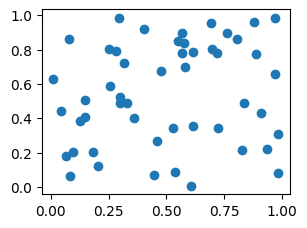

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
# 固定大小
plt.scatter(x, y)  # 所有点大小相同
plt.gcf().set_size_inches(3.2, 2.4)  # 该代码在我们详细讲述Figure对象的时候讲解

- 代码说明：
    - 我们使用代码`plt.gcf().set_size_inches(3.2, 2.4)`来控制Figure图表的大小。
    - `y = np.random.rand(50)`用来生成50个0-1之间的随机数。

- s参数说明：
    - 设置标记marker的大小，单位是point平方，这意味着s设置的是点的面积。比如s=100表示散点的大小事100平方点（也翻译成磅），散点的直径实际是s的平方根。
    - s参数类型可以是float类型，表示所有散点大小一样；也可以是数组，对应上面x，y中每个点的大小。
    - s参数的值是相对的，实际显示效果会受到Figure对象的尺寸和dpi设置的影响。
    - 最后散点的大小还受linewidth与edgecolors影响，因为边界线的中心与marker的边缘。如果散点尺寸小于linewidth，会产生伪影（就是边界会自我重叠）
    - marker默认尺寸是`rcParams['lines.markersize'] ** 2`设置的。
    - **提示**：关于marker的尺寸问题：
        - 在plot中也有marker属性设置（来自Line2D的属性），其中markersize采用的是直径为单位，这里s采用的是面积单位，在使用的时候需要注意。

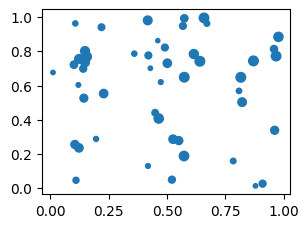

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 49, 50)
# 固定大小
plt.scatter(x, y, s)  #  s指定点的大小
plt.gcf().set_size_inches(3.2, 2.4)  

- 代码说明：
    - 在numpy1.16以后，不再推荐使用`numpy.random.randint(low, high=None, size=None, dtype=in)`函数来生成low与high之间的随机整数，访问模块也作了改变`random.RandomState.randint(low, high=None, size=None, dtype=int)`。
    - 在最新的numpy版本中使用`class numpy.random.Generator`对象完成，按照Python的设计模式，还提供了一个函数来构造Generator对象。

- c参数说明：
    - 设置marker标记的颜色，类似可以是颜色（所有散点一样的颜色），或者颜色列表（对应每个散点颜色，列表长度与x，y长度一样），也可以是数字数组。
    - 注意：**如果想所有散点都一样的颜色，需要使用关键字参数形式。**
    - 最终影响散点颜色的主要是c参数与facecolor参数。
    - c的颜色表示：
        - 直接颜色表示，比如"red"或者"#RRGGBBAA"(R表示红色位，G表示绿色位，B表示蓝色位，A表示透明通道),或者`[[R, G, B, A]]`表示（不能使用元组表示颜色，容易与单数值歧义，导致启动颜色映射）
        - 也可以是一个数值或者数值数组，这些数值可以映射到颜色图（通过camp参数与norm参数）。
    - 如果不指定c参数，则使用Axes的循环颜色决定（效果看起来像随机颜色），循环颜色由环境参数`rcParams["axes.prop_cycle"]`设置，默认是10额颜色循环：
        - `cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])`

- 直接使用颜色值的例子

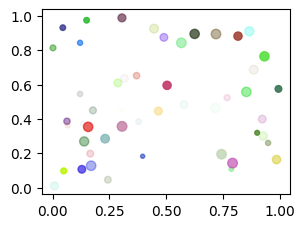

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 49, 50)
# c = "red"  # 所有点一个颜色（字符串颜色表示）
# c = "#FF000088"  # 所有点一个颜色（16进制颜色表示，最后两个8表示透明度）
# c = [[1, 0, 0, 0.5]] # 如果使用10进制表示颜色，必须使用二维数组，数组的每行必须是3,与4长度，而且只能是0-1之间的小数
c = np.random.default_rng().random(size=(50, 4), dtype=float)
# 固定大小
plt.scatter(x, y, s, c)  #  s指定点的大小
plt.gcf().set_size_inches(3.2, 2.4)  

- 代码解释：
    - 上面例子，我们使用了三种格式表示颜色："red"，"#RRGGBBAA",列数为3与4的二维数组。
    - 散点的颜色可以都一样，也可以每个散点一个颜色。使用二维数组最容易生成每个散点一个随机颜色值。
    - `c = np.random.default_rng().random(size=(50, 4), dtype=float)`代码生成了一个二维数组，每行表示一个颜色，而且支持透明度。

- 使用数值与颜色图(cmap)的例子

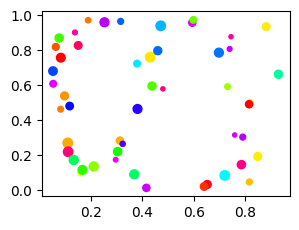

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 49, 50)
c =  np.random.rand(50)
# 固定大小
plt.scatter(x, y, s, c, cmap="hsv")  # 使用默认cmap="viridis"
plt.gcf().set_size_inches(3.2, 2.4)  

- 代码说明：
    - `c =  np.random.rand(50)`代码生成50个0-1之间的小数，小数不是颜色，但是可以映射到颜色，其中每个小数都代表颜色图中的一个颜色值。
    - matplotlib提供很多内置的颜色图，使用者也可以自己构造颜色图，我们这里使用了内置的颜色图"hsv",因为比较鲜艳。关于颜色图的使用以及内置颜色图，我们会用专门的主题介绍。如果想使用内置颜色图，可以参考如下文档使用：`https://matplotlib.org/stable/users/explain/colors/colormaps.html#colormaps`

- marker参数说明：
    - plot函数中，我们已经有基本的marker使用经验，但是那个是简略使用方式，真正的marker实际在matplotlib中由MarkerStyle对象负责，功能也强大的多。而且还可以使用环境参数`rcParams["scatter.marker"]`设置默认marker标记。
    - 所以marker参数可以有两种使用方式：
        - 使用字符串的简写marker设置（**推荐**），而且比plot中的marker更加丰富（场景不同）。
        - 使用MarkerStyle对象来负责设置marker标记。

- marker简写说明：
    - plot的marker与scatter函数中的marker还是略有不同的，增加部分内容。大家在使用的时候要注意这一点，如果记不住，就使用matplotlib的官方文档查阅：`https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers`。

- scatter中增加的marker内容（注意：数字1与字符串"1"的区别）
|字符|含义描述|
|---|--------|
|0|左边刻度|
|1|右边刻度|
|2|下边刻度|
|3|上边刻度|
|4|左边插入符号|
|5|右边插入符号|
|6|上边插入符号|
|7|下边插入符号|
|8|左边插入符号（底部居中）|
|9|右边插入符号（底部居中）|
|10|上边插入符号（底部居中）|
|11|下边插入符号（底部居中）|
|"none"或者"None"|无marker|
|" "或者""|无marker|
|`"$...$"`|中间...表示可以使用数学符号描述（不是Latex语法，而是matplotib提供的mathtext语法）|
|verts|用于标记marker路径顶点的一系列(x, y)坐标对。标记marker的中心位于(0, 0)处，且其大小已归一化，以确保创建的路径完全包含在单位单元格内|
|path|matplotlib.path.Path对象（负责绘制标记marker的路径顶点）|
|(numside, 0, angle)|numside多边形，numside指定边数，angle指定旋转角度|
|(numside, 1, angle)|numside多边形（星图形），numside指定边数，angle指定旋转角度★|
|(numside, 2, angle)|numside多边形（星符号），numside指定边数，angle指定旋转角度✱|


- marker使用例子：

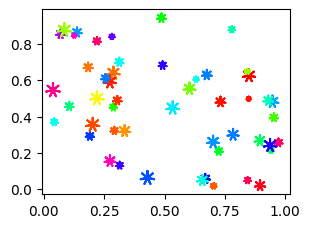

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 100, 50)
c =  np.random.rand(50)
# 固定大小
# plt.scatter(x, y, s, c, cmap="hsv", marker=1)  # marker是左边刻度
# plt.scatter(x, y, s, c, cmap="hsv", marker="")   # 无marker，其实就是不输出散点
# plt.scatter(x, y, s, c, cmap="hsv", marker="$A^2$") # 使用数学公式
# plt.scatter(x, y, s, c, cmap="hsv", marker="$\sum$") # 使用数学符号mathtext
# plt.scatter(x, y, s, c, cmap="hsv", marker=[(0.5, 0), (0, 0.5), (0.5, 1), (1, 0.5)])  # verts顶点列表：定义一个菱形
# from matplotlib.path import Path
# plt.scatter(x, y, s, c, cmap="hsv", marker=Path([[0.5, 0], [0, 0.5], [0.5, 1], [1, 0.5]])) # 效果与上面一样，但是使用Path对象
# plt.scatter(x, y, s, c, cmap="hsv", marker=(5, 0, 0))  # 5边形，不旋转
# plt.scatter(x, y, s, c, cmap="hsv", marker=(7, 1, 0))  # 7角星
plt.scatter(x, y, s, c, cmap="hsv", marker=(7, 2, 0))  # 7星符
plt.gcf().set_size_inches(3.2, 2.4)  

- 代码说明：
    - 我们使用了marker的各种形式，其中`$...$`可以使用amthtext，这是matplotib提供的语法，具体的语法与符号可以参考文档：`https://matplotlib.org/stable/users/explain/text/mathtext.html#mathtext`
    - Path也是属于绘图的知识范畴，Path对象比较简单，我们这里没有展开介绍，仅仅是简单使用。

- cmap，norm，vmin, vmax参数介绍
    - 这三组参数（vmin,vmax是一组）是相关的。这涉及cmap的工作原理：`数据值 → 归一化到 [0,1] → 映射到colormap颜色`。
        - 数据值在`[0,1]`之间，就不存在归一化的问题
        - 如果数据值不在0-1之间，则归一化（把数据压缩到`0-1`之间）就有两种方式
            - 使用norm参数指定的Normalize对象，或者字符串命名的内置归一化对象。
            - 使用vmin与vmax参数归一化： `(value - vmin) / (vmax - vmin)`
        - 所以norm参数与vmin,vmax只需要使用一个就行，明显vmin,vmax使用简单一些。如果两个都存在，则norm有效。如果c是颜色值格式，这两组参数都无效。在norm是Normalize对象的时候，norm与vmin，vmax同时使用时，会报错。但是norm是字符串时是可以的。
        - 从Normalize类的构造器`class matplotlib.colors.Normalize(vmin=None, vmax=None, clip=False)`可以看出，Normalize实际是vmin，vmax的对象封装。
    - cmap只有在c参数是数值的时候有作用，对c参数是颜色格式的情况下，cmap参数无效。
    - cmap可以是字符串类型的cmap（内置的cmap都是使用字符串命名），也可以是Colormap对象，默认的值是"viridis"，默认值可以在` rcParams["image.cmap"]`环境参数设置。

- 下面我们重点介绍内置cmap，对于Colormap对象的使用，我们用专门主题说明。

- 内置cmap列表
    - 我们可以使用如下代码列出所有内置的cmap。

In [39]:
from matplotlib import colormaps
print(list(colormaps))

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', '

- 上面的cmap可以按照颜色特点分类，官方提供了一个代码（封装为plot_color_gradients函数，详细代码在下面），用来直观观察每个cmap的颜色特点。

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))

def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list

- 第一组(Sequential)

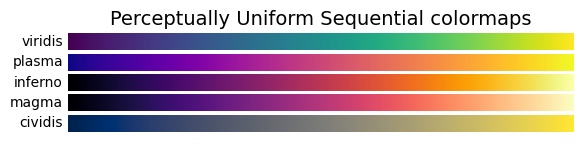

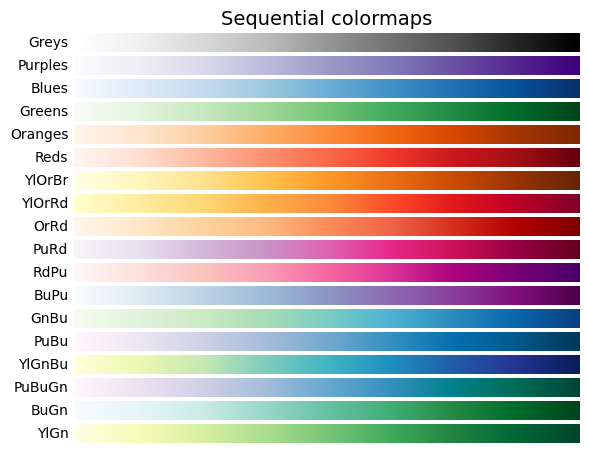

In [42]:
plot_color_gradients('Perceptually Uniform Sequential',
                     ['viridis', 'plasma', 'inferno', 'magma', 'cividis'])
plot_color_gradients('Sequential',
                     ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
                      'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
                      'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'])

- 第二组(Sequential2)

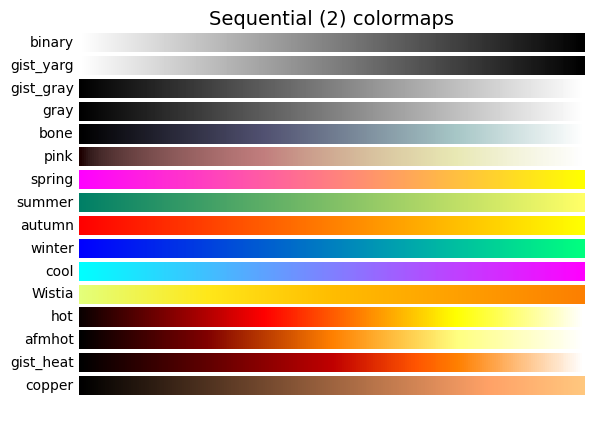

In [43]:
plot_color_gradients('Sequential (2)',
                     ['binary', 'gist_yarg', 'gist_gray', 'gray', 'bone',
                      'pink', 'spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper'])

- 第三组(Diverging)

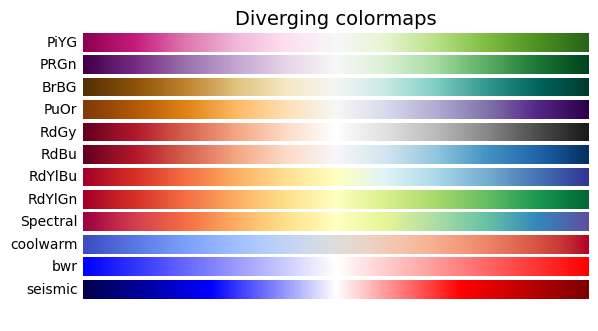

In [50]:
plot_color_gradients('Diverging',
                     ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
                      'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic'])
# 'berlin',  'managua' 'vanimo'已经失效

- 第四组(Cyclic)

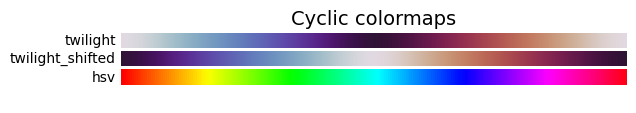

In [51]:
plot_color_gradients('Cyclic', ['twilight', 'twilight_shifted', 'hsv'])

- 第五组(Qualitative)

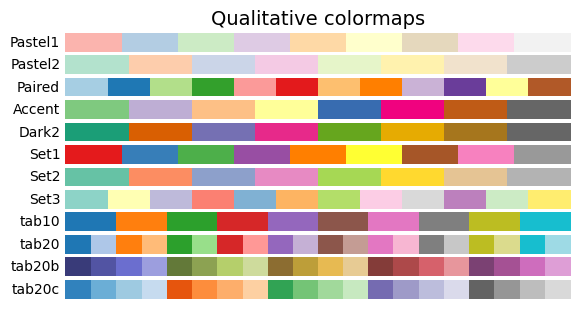

In [52]:
plot_color_gradients('Qualitative',
                     ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2',
                      'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b',
                      'tab20c'])

- 第六组(Miscellaneous)

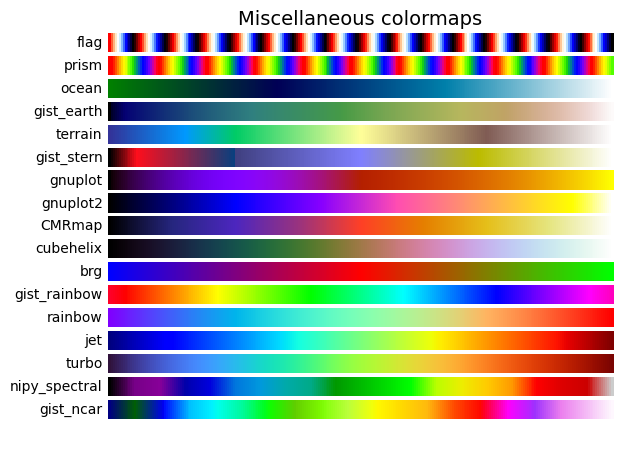

In [53]:
plot_color_gradients('Miscellaneous',
                     ['flag', 'prism', 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet',
                      'turbo', 'nipy_spectral', 'gist_ncar'])

- cmap, vmax, vmin, norm的使用例子：

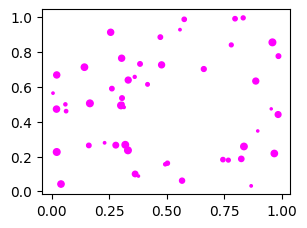

In [59]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 100, 50)
c =  np.random.rand(50)
# 固定大小
# plt.scatter(x, y, s, c, marker='.', cmap="spring", vmin=0, vmax=100)  # 因为c是0-1之间的，通过vmin, vmax的归一化，c的值压缩到接近0，颜色都早spring的底端
from matplotlib.colors import Normalize
plt.scatter(x, y, s, c, marker='.', cmap="spring", norm=Normalize(0, 100))  # 这行代码与上面一行的作用完全一样，只是使用Normalize对象而已。
plt.gcf().set_size_inches(3.2, 2.4)  

- 代码说明:
    - 代码行`plt.scatter(x, y, s, c, marker='.', cmap="spring", vmin=0, vmax=100)`与`plt.scatter(x, y, s, c, marker='.', cmap="spring", norm=Normalize(0, 100))`完全一样，一个使用vmin、vmax参数，一个使用Normalize对象。
    - norm或者(vmin，vmax)用来对c的值进行归一化，并最终映射到颜色图。
        - cmap参数可选，matplotlib会使用默认的cmap。

- scatter其他参数介绍
    - alpha：参数用来设置散点颜色的透明度，参数是0-1之间的小数。0表示全透明，1表示不透明。
    - linewidths：参数设置marker边界的宽度，默认是1.5，该值可以使用环境参数`rcParams["lines.linewidth"]`设置。该参数也可以是数组，数组长度与散点个数一样，可以对每个散点设置不同的边界宽度。
    - edgecolors：参数设置marker边线的颜色，如果是一个值，表示所有散点颜色一样，也可以使用数组，对每个散点设置不同的marker边线颜色。还可以使用"face"表示与marker的颜色一样，还可以使用"none"与None，表示不绘制marker的边线。**edgecolors不使用cmap，要求是颜色值。**
    - colorizer：参数作用等于norm与cmap的封装。类型是Colorizer对象，默认值是None，值为None的时候，matplotlib自动使用norm与cmap创建Colorizer对象。
    - plotnonfinite：是否绘制无穷或者非数值数据。默认是False。

- scatter函数的alpha、linewidths、edgecolors、colorizer使用例子：

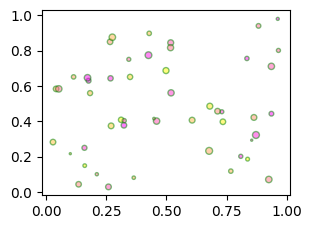

In [13]:
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(9, 100, 50)
c =  np.random.rand(50)

from matplotlib.colors import Normalize
from matplotlib.colorizer import Colorizer
plt.scatter(x, y, s, c, 
            marker='.', 
            colorizer=Colorizer("spring", Normalize(0, 1)), 
            linewidths=1,
            edgecolors="green",
            alpha=0.5
)  # 使用Colorizer替换cmap与norm（或者vmin，vmax）。

plt.gcf().set_size_inches(3.2, 2.4)  

- 代码说明：
    - `Colorizer`在早期版本不支持，如果该代码运行出错，请升级matplotlib到最新版本（这里使用的是3.10.7）。
    - 上面代码linewidth，edgecolors可以使用数组来设置每个对应散点的边线宽度与颜色，我们使用一个值，设置所有散点的边线宽与颜色一样。
    - alpha值设置的透明度，对边线也有作用。

- data参数的使用与plot函数一样，这里不赘述。
    - 但是data中可以使用列来指定如下几个参数：x, y, s, linewidths, edgecolors, c, facecolor, facecolors, color

- `**kwargs`参数中使用来自`PathCollection`对象的属性。

- data与`**kwargs`参数使用例子：
    - `**kwargs`使用PathCollection对象的mouseover属性。

In [5]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

# 生成随机散点示例数据：50个
x = np.random.rand(50)  # [0-1)之间的随机数
y = np.random.rand(50)
s = np.random.default_rng().integers(100, 400, 50)
c =  np.random.rand(50)
edgecolors = np.random.default_rng().random(size=(50, 4), dtype=float)
linewidths = np.random.default_rng().integers(1, 3, 50)

data = {
    "x": x,
    "y": y, 
    "s": s,
    "c": c,
    "edgecolors": edgecolors,
    "linewidths": linewidths
}
from matplotlib.colors import Normalize
from matplotlib.colorizer import Colorizer
plt.scatter("x", "y", "s", "c", 
            marker='.', 
            linewidths="linewidths",
            edgecolors="edgecolors",
            data=data,
            cmap="hsv",
            alpha=0.5
)  # 使用Colorizer替换cmap与norm（或者vmin，vmax）。

plt.gcf().set_size_inches(10, 8)  

- 代码说明：
    - `edgecolors = np.random.default_rng().random(size=(50, 4), dtype=float)`是二维数组表示的颜色，不能用0-1的一维数组，并使用cmap来映射颜色。
    - data中可以指定x, y, s, linewidths, edgecolors, c, facecolor, facecolors, color需要使用的等字段。
    - PathCollection中属性在参数中都基本上有，这类没有使用。

### (3) 饼图绘制-pie

- pyplot中pie函数负责绘制饼图，pie函数原型定义如下：

```python
matplotlib.pyplot.pie(
    x,   # 饼图绘制的数据，每块饼的大小（比例）
    *,   # --------位置参数与关键字参数分隔线---------
    explode=None, # 每块饼的半径（长短） 
    labels=None,  # 每块饼的标签
    colors=None,  # 每块饼的颜色
    autopct=None, # 标记每块饼的百分比的格式
    pctdistance=0.6,  # 百分比的位置，以到饼图圆心的距离度量（1表示饼图边界，小于1在饼内，大于1在饼外）
    shadow=False, # 是否添加阴影效果
    labeldistance=1.1,  # 标签的位置，以到饼图圆心的距离度量
    startangle=0,  # 饼绘制的开始角度，这个决定第一块饼绘制的开始位置
    radius=1,  # 饼的半径
    counterclock=True,  # 饼绘制的方向，反时针（True）或者顺时针
    wedgeprops=None,  # 用来设置饼的属性，属性来自matplotlib.patches.Wedge对象
    textprops=None, # 设置每块饼的文本属性
    center=(0, 0),  # 饼在坐标系中的圆心位置
    frame=False,  # 是否绘制坐标系框架
    rotatelabels=False,  # 每块饼的标签是否旋转。
    normalize=True, # 是否对饼的数据x进行归一化
    hatch=None, # 版本3.7以后提供的参数，花纹背景（PPT中那种图案背景）
    data=None)  # 使用结构数据，x可以使用数据字段获取数据
```

- pie函数默认返回2个数组，第一个是饼图的每个饼对象(matplotlib.patches.Wedge),第二个数组是Text对象（用来显示label属性）
    - 如果设置autopct=True，则还会返回百分比标签Text对象。

- x参数与normalize参数说明：
    - x参数是一维数组，用来表示每一块饼的大小（份额）。数组的元素可以是任意值，默认情况下，这些值会被归一化，归一化后的x值满足sum(x)=1，这等于每块饼的大小是相对比列。
    - normalize参数默认是True，会自动对x的值进行归一化。如果是False，则x的值在设置的时候就需要遵循sum(x)=1的规则，否则：
        - sum(x)<1：按照指定值绘制饼，不够的区域不会绘制
        - sum(x)>1: 绘制的时候会报错误ValueError。
    - x参数是必须的，没有默认值。

([<matplotlib.patches.Wedge at 0x285ba2c16d0>,
 [Text(1.0461621649530053, 0.3399187029582827, ''),
  Text(0.33991865722907993, 1.0461621798113232, ''),
  Text(-1.046162235191088, 0.33991848678762215, ''),
  Text(-0.6465635702962116, -0.8899188443705505, '')])

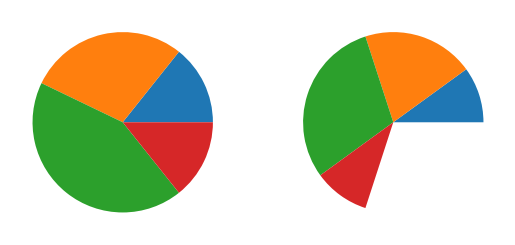

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [10, 20, 30, 10]
plt.subplot(121)
plt.pie(x, normalize=True)  # x使用位置参数形式，也可以使用关键字参数x=x。normalize默认为True
# plt.pie(x, normalize=False)  # normalize为False，而且sum(x) > 1, 所以该语句会报错 

plt.subplot(122)
x = [0.1, 0.2, 0.3, 0.1]
plt.pie(x, normalize=False)  # normalize默认为True

- 代码说明：
    - `plt.pie(x, normalize=False)`代码会报错，因为normalize=False，sum(x)必须<=1。
    - `plt.pie(x, normalize=False)`绘制中`x = [10, 20, 30, 10]`数据会归一化，因为normalize=True。
    - `plt.pie(x, normalize=False)`绘制中`x = [0.1, 0.2, 0.3, 0.1]`数据不足1的部分会空余,因为normalize=False

- labels、labeldistance、explode与colors参数说明：
    - laebls设置每个饼的标签，类型是字符串数组。labels的标签与x的数据一一对应。
    - 如果没有设置labels属性，默认都是""。
    - labeldistance参数这是标签离圆心的距离，默认是1.1（并的半径是1），labeldistance不能是数组。
    - explode参数设置每个饼的顶点离圆心的距离。
    - colors设置么个饼的颜色，类型是颜色数组。colors可以不与x长度一致，不够的会循环使用。
    - 不设置colors值，会使用当前激活的颜色循环，这个与散点图一致。

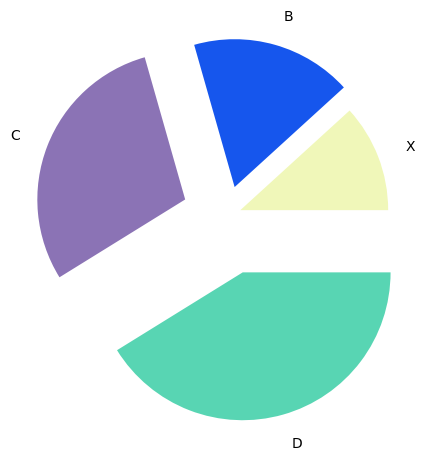

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [20, 30, 50, 70]
labels = ["A", "B", "C", "D"]
labeldistance = 1.2
explode = [0.1, 0.2, 0.3, 0.4]
colors = np.random.default_rng().random(size=(4, 3), dtype=float)  
wedges, texts = plt.pie(x, explode=explode, labels=labels, labeldistance=labeldistance, colors=colors)
texts[0].set_text("X")  # 通过标签文本对象修改标签

- 代码说明：
    - `colors = np.random.default_rng().random(size=(4, 3), dtype=float) `生成4个RGB颜色。

- 使用hatch设置每个饼的图案。
    - 内置图案使用字符串名字表示。如果只有一个图案，则每个饼都一样的图案。如果是数组，则每个饼有自己的图案。
    - 图案字符串有：`['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']`, 其中图案可以使用多个，多个一样的可以增加图案的密度。
    - 下面是官方提供的代码，可以看到每个图案的可视化效果

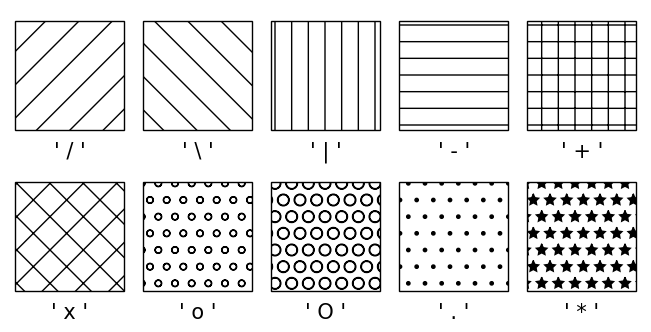

In [24]:
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle

fig, axs = plt.subplots(2, 5, layout='constrained', figsize=(6.4, 3.2))
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
def hatches_plot(ax, h):
    ax.add_patch(Rectangle((0, 0), 2, 2, fill=False, hatch=h))
    ax.text(1, -0.5, f"' {h} '", size=15, ha="center")
    ax.axis('equal')
    ax.axis('off')

for ax, h in zip(axs.flat, hatches):
    hatches_plot(ax, h)

- 可以使用多个一样图案增加密度：

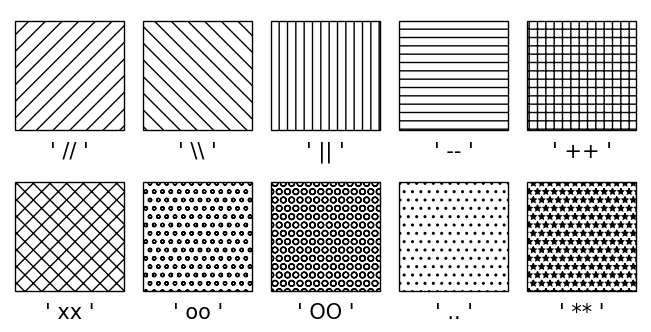

In [25]:
fig, axs = plt.subplots(2, 5, layout='constrained', figsize=(6.4, 3.2))
hatches = ['//', '\\\\', '||', '--', '++', 'xx', 'oo', 'OO', '..', '**']
for ax, h in zip(axs.flat, hatches):
    hatches_plot(ax, h)

- 使用图案组合。

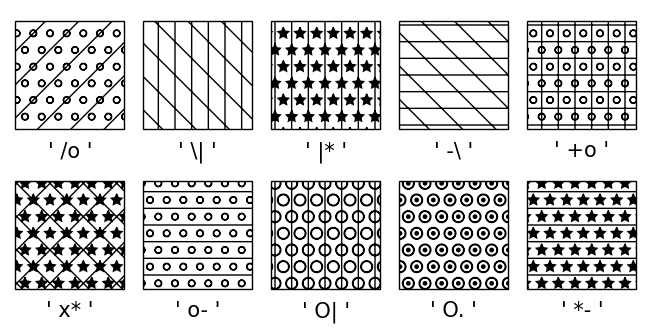

In [26]:
fig, axs = plt.subplots(2, 5, layout='constrained', figsize=(6.4, 3.2))
hatches = ['/o', '\\|', '|*', '-\\', '+o', 'x*', 'o-', 'O|', 'O.', '*-']
for ax, h in zip(axs.flat, hatches):
    hatches_plot(ax, h)

- 在pie饼图中使用图案的例子

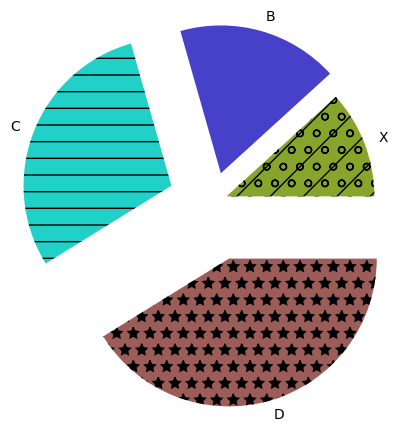

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [20, 30, 50, 70]
labels = ["A", "B", "C", "D"]
explode = [0.1, 0.2, 0.3, 0.4]
colors = np.random.default_rng().random(size=(4, 3), dtype=float)  
hatch = [r"/o", None, r"-", r"*"]

wedges, texts = plt.pie(x, explode=explode, labels=labels, colors=colors, hatch=hatch)
texts[0].set_text("X")  # 通过标签文本对象修改标签

- 代码说明：
    - `hatch = [r"/o", None, r"-", r"*"]`代码中，如果不想设置图案，则使用None值即可。

- autopct、pctdistance参数说明：
    - autopct参数用来设置饼的百分比格式，类型是字符串，或者返回格式化百分比的函数，函数的参数是百分比值。
    - pctdistance参数指定百分比离圆心的距离。参数类型是float，不能是数组。

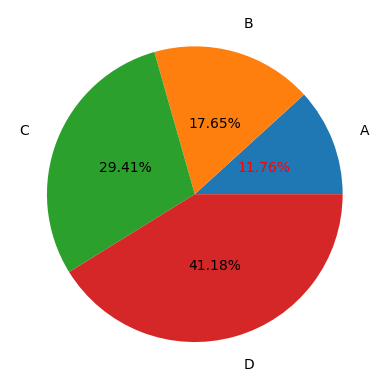

In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [20, 30, 50, 70]
labels = ["A", "B", "C", "D"]
wedges,texts1, texts2 = plt.pie(x, labels=labels, labeldistance=1.2, autopct="%04.2f%%", pctdistance=0.5)
texts2[0].set_color("red")

- 代码说明：
    - autopct支持的格式字符串支持%格式字符串(fmt % pct)

- shadow参数说明（V3.8以后支持）：
    - 在饼图中绘制阴影，参数类型下面几种情况：
        - 逻辑值bool：是否绘制阴影。
        - 字典dict:中是`matplotlib.patches.Shadow`对象中的属性，用来定制更加详细的阴影绘制。比如：阴影的颜色，阴影的图案，阴影的边线等。

([<matplotlib.patches.Wedge at 0x285bc5b5bd0>,
 [Text(1.0461621649530053, 0.3399187029582827, ''),
  Text(0.33991865722907993, 1.0461621798113232, ''),
  Text(-1.046162235191088, 0.33991848678762215, ''),
  Text(-0.6465635702962116, -0.8899188443705505, '')])

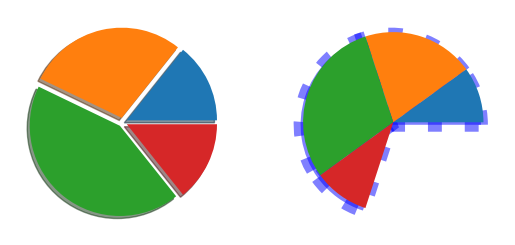

In [66]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [10, 20, 30, 10]
plt.subplot(121)
explode = [0.05, 0.05, 0.05, 0.05]
plt.pie(x,explode=explode, shadow=True)  # shadow阴影为bool的方式

plt.subplot(122)
x = [0.1, 0.2, 0.3, 0.1]
shadow = {
    "color": "blue",
    "linewidth": 10,
    "linestyle": ":"
}
plt.pie(x, normalize=False, shadow=shadow)  # shadow为字典的方式

- 代码说明：
    - 代码中使用的shadow参数的属性，我们没有在这里详细讲解，我们会在后面专门主题介绍Shadow对象的使用，包括Shadow的属性。
    - 代码中我们使用逻辑值与字典说明的shadow的使用方式与效果。

- startangle、radius、counterclock参数说明：
    - startangle：饼图开始绘制角度，默认值是0°，参数类型是float类型。注意：使用的是角度，而不是弧度。
    - radius：饼图的半径，默认值是1，参数类型是float类型。该值决定了饼图的大小，如果是2，则饼图放大2倍。
    - counterclock：饼图绘制方向，类型是逻辑值，默认是True，表示逆时针绘制。 如果是False，表示顺时针绘制。

([<matplotlib.patches.Wedge at 0x285bc7e1bd0>,
 [Text(-0.339918873399729, 1.0461621095732052, ''),
  Text(-1.0461621541481756, 0.33991873621212615, ''),
  Text(-0.33991831634615544, -1.046162290570825, ''),
  Text(0.8899189497091149, -0.6465634253100202, '')])

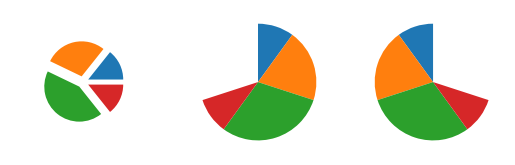

In [71]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [10, 20, 30, 10]
plt.subplot(131)
explode = [0.1, 0.1, 0.1, 0.1]
plt.pie(x,explode=explode, radius=0.6)  # 小于1，表示缩小。大于1表示放大

plt.subplot(132)
x = [0.1, 0.2, 0.3, 0.1]
plt.pie(x, normalize=False, startangle=90, counterclock=False)  # 开始角度90度，反时针

plt.subplot(133)
x = [0.1, 0.2, 0.3, 0.1]
plt.pie(x, normalize=False, startangle=90, counterclock=True)  # 开始角度90度，顺时针


- 代码说明：
    - radius参数从效果来说，可以放大缩小饼图。
    - startangle、counterclock可以控制饼图的方位。

- center与frame参数说明：
    - center参数是一个坐标（长度为2的元组），用来设置饼图的位置。
    - frame用来设置是否绘制坐标系，参数类型是逻辑值，默认值是False。

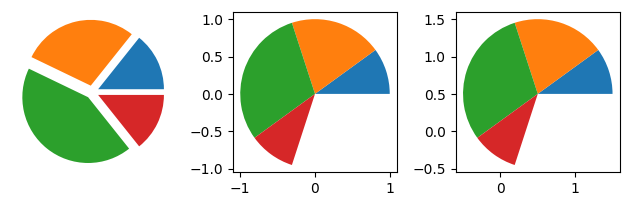

In [74]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [10, 20, 30, 10]
plt.subplot(131)
plt.pie(x,explode=explode, center=(0, 0), frame=False)   # center， frame都使用默认值。  

plt.subplot(132)
x = [0.1, 0.2, 0.3, 0.1]
plt.pie(x, normalize=False, center=(0, 0), frame=True)  # center默认值，frame设置为True

plt.subplot(133)
x = [0.1, 0.2, 0.3, 0.1]
plt.pie(x, normalize=False, center=(0.5, 0.5), frame=True)  # center设置为第一象限内坐标 ，frame设置为True
plt.tight_layout()  # 自动调整布局

- rotatelabels、textprops、wedgeprops参数说明：这三个参数都是对饼图进行更加详细的设置：
    - rotatelabels用来旋转标签，参数类型是逻辑值，默认值是False（不旋转标签），旋转的角度与饼的角度位置有关，旋转是自动计算的。
    - wedgeprops用来设置饼的属性，属性都是来自`matplotlib.patches.Wedge`对象，包括颜色、图案、边线与边线颜色等，部分属性与参数重叠。参数类型是字典。
    - textprops用来设置文本属性，属性来自Text对象的属性。参数类型是字典。

([<matplotlib.patches.Wedge at 0x285bc054b90>,
 [Text(1.0811626238968959, 0.5206605234587883, 'A'),
  Text(-0.2670252788091667, 1.1699134585416509, 'B'),
  Text(-0.7481875609118822, -0.9381979395078253, 'C'),
  Text(1.0811631338876628, -0.5206594644508131, 'D')])

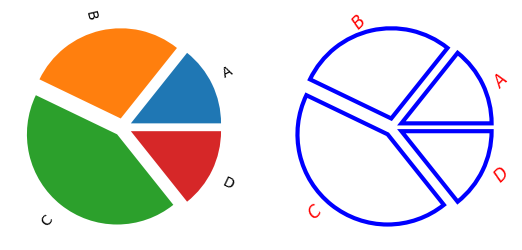

In [77]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = [10, 20, 30, 10]
labels = ["A", "B", "C", "D",]

plt.subplot(121)

plt.pie(x,explode=explode, labels=labels, rotatelabels=True)   # 旋转标签

x = [10, 20, 30, 10]
labels = ["A", "B", "C", "D"]
wedgeprops = {
    "ec": "blue",
    "lw": 3,
    "fill": False
}
textprops = {
    "c": "RED",
    "size": 12,
    "style": "italic",
    "rotation": 45   # 旋转标签的角度（这个旋转需要自己计算选装角度，或者采用统一的旋转角度）
}
plt.subplot(122)
plt.pie(x,explode=explode, labels=labels, wedgeprops=wedgeprops, textprops=textprops)  # 使用文本属性旋转标签


- 代码说明：
    - wedgeprops、textprops等属性设置，没有像plot、scatter函数采用`**kwargs`，而且这些属性有的是与pie函数的参数作用一样，参数基本上能够满足大部分需求。

- data参数的使用与plot中介绍的一样，这里不重复介绍。

----------

> 通过plot、scatter、pie函数的讲解，我们掌握了很多参数的使用方式，在matplotlib中，大部分参数在不同的函数的作用都一样，所以下面我们主要介绍其他函数的使用，重点介绍数据特点与重要的参数。

### (4) 线段绘制-vlines,hlines

- 这两个函数用来绘制一组线段，而且函数功能一样,只是绘制方向不同，vlines按照垂直方向绘制，hlines按照水平方向绘制。vlines与hlines函数的原型定义如下：

```python
matplotlib.pyplot.vlines(
    x,   # 垂直线的x位置，参数类型是float（一条垂直线）或者数组（多条垂直线）
    ymin, ymax,  # 垂直线的最高位置ymax与最低位置ymin，两个参数也决定了垂直线长度。参数类型floa(对应x的一条垂直线)或者数组（对应x的多条垂直线）
    colors=None, # 设置垂直线的颜色，参数类型是一个颜色（所有垂直线颜色一样）或者颜色数组（对应每条垂直线的颜色），线条颜色可以通过环境参数rcParams["lines.color"]设置，默认值是`c0`，`c0`表示循环颜色中的第一个。
    linestyles='solid', # 线条样式，可以取值：{'solid'（实线）, 'dashed'(虚线，就是线段构成的虚线), 'dashdot'（虚点线，就是线段与点构成的虚线）, 'dotted'（点线，就是点构成的虚线）},默认值是'solid'
    *,   # ---------------位置参数与关键字参数的分隔符号
    label='', # 参数设置垂直线的标签。参数类型是字符串，默认值是""。
    data=None, # 可以下标访问的结构数据（字典，或者pandas的DataFrame），结构数据中的字段支持：x, ymin, ymax, colors四个参数。
    **kwargs  # 参数主要用LineCollection对象中的属性来设置垂直线属性。
)  

############################
matplotlib.pyplot.hlines(y, xmin, xmax, colors=None, linestyles='solid', *, label='', data=None, **kwargs)
```

- 参数说明：
    - x参数：
        - 直线的x位置，参数类型是float（一条垂直线）或者数组（多条垂直线）
    - ymin, ymax参数：
        - 垂直线的最高位置ymax与最低位置ymin，两个参数也决定了垂直线长度。参数类型floa(对应x的一条垂直线)或者数组（对应x的多条垂直线）
    - colors=None参数
        - 设置垂直线的颜色，参数类型是一个颜色（所有垂直线颜色一样）或者颜色数组（对应每条垂直线的颜色），线条颜色可以通过环境参数`rcParams["lines.color"]`设置，默认值是`c0`(就是colors=None的颜色值)，`c0`表示循环颜色中的第一个。
    - linestyles='solid'参数：
        - 线条样式，可以取值：{'solid'（实线）, 'dashed'(虚线，就是线段构成的虚线), 'dashdot'（虚点线，就是线段与点构成的虚线）, 'dotted'（点线，就是点构成的虚线）},默认值是'solid'
    - label=''参数：
        - 参数设置垂直线的标签。参数类型是字符串，默认值是""。
    - data=None参数：
        - 可以下标访问的结构数据（字典，或者pandas的DataFrame），结构数据中的字段支持：x, ymin, ymax, colors四个参数。
    - `**kwargs`参数：
        - 参数主要用LineCollection对象中的属性来设置垂直线属性。

- 返回值说明：
    - 返回LineCollection对象（线段集）

- 使用hlines与hlines绘制线段的例子：

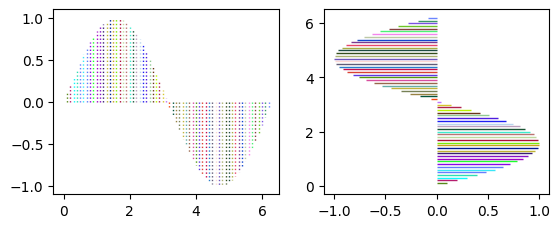

In [19]:
import matplotlib.pyplot as plt
import numpy as np
# 随机数生成器
generator = np.random.default_rng(seed=202510141700)

plt.figure(figsize=(6.4, 2.4))

# 参数例子
x = np.arange(0.0, 2*np.pi, 0.1) # 从0.0到2π，间隔0.1产生一个数据
ymin = np.zeros_like(x, dtype=float)  # 与x对应的数组，值都是0
ymax = np.sin(x)  # 与x对应的数组, 值是x的正弦

colors = generator.random(size=(x.shape[0], 3), dtype=float) # 随机产生一个二维数组的颜色值
linestyles = 'dotted' # 线段样式
label = "" # 标签（每条线段都一样）
linewidths = 1  # 来自matplotlib.collections.LineCollection对象的属性,该参数也可以对每个线段设置不同的粗细

plt.subplot(121)
plt.vlines(x=x, ymin=ymin, ymax=ymax, colors=colors, linestyles=linestyles, label=label, linewidths=linewidths)
plt.subplot(122)
hl = plt.hlines(y=x, xmin=ymin, xmax=ymax, colors=colors, linestyles="solid", label=label)
hl.set_linewidths(1)

- 代码说明：
    - 在代码中，使用matplotlib.collections.LineCollection对象的linewidths属性用了两种方式：
        - 使用参数设置linewidths属性：`plt.vlines(x=x, ymin=ymin, ymax=ymax, colors=colors, linestyles=linestyles, label=label, linewidths=linewidths)`
        - 使用对象设置linewidths属性：`hl.set_linewidths(1)`

### (5) 条形图绘制-bar与barh

- 条形图绘制相关的函数一共三个相关函数：
    - bar：绘制垂直条形图
    - barh：绘制水平条形图
    - bar_label：设置bar与barh的标签属性。

- 下面是三个函数的函数原型定义与参数说明：

```python
matplotlib.pyplot.bar(
    x, # bar的x坐标，参数类型是float(一个bar)或者数组（多个bar，可以是字符串，等分）
    height, width=0.8,  # bar的高度与宽度 ，参数类型与x一样且对应。 其中width默认值是0.8
    bottom=None,  # bar下端的y坐标，参数与x一样且对应，当bottom=None，默认是0，就是与x轴对齐。
    *, 
    align='center',  # bar以x为参照的对齐方式。, 因为bar有宽度，所以x可以在bar左边，也可以在中间。取值{'center', 'edge'}，edge就是x在左边。
    data=None,  # 结构化数据，字段或者DataFrame类似的结构化数据，字段支持x，height，width，bottom字段
    **kwargs)  # 来自Rectangle对象的属性以及其他参数。

#########################
matplotlib.pyplot.barh(y, width, height=0.8, left=None, *, align='center', data=None, **kwargs)
```

- `**kwargs`参数说明：
    - `**kwargs`不仅仅是来自Rectangle对象的属性，还支持一些在参数中没有列出来的可选参数（这些参数一般都是通用而又熟悉的属性，所以我们仅仅简单列出，不再赘述）：
        - color参数：类型颜色或者颜色数组,与facecolor是同一个参数，是facecolor的别名。
        - facecolor参数：类型颜色或者颜色数组
        - edgecolor参数：类型颜色或者颜色数组
        - linewidth参数：类型float或者数组
        - tick_label参数：设置bar的刻度标签，参数类型是字符串或者字符串数组, 没有设置参数，或者参数为None的时候，使用默认的数字刻度标签
        - label参数：每个bar的标签，类型是字符串或者字符串数组。
        - log参数：设置x坐标轴使用对数刻度（刻度不是均等的，而是log函数变化）。

- bar与barh函数返回BarContainer对象。

- bar与barh使用的例子：x参数与heights参数的使用

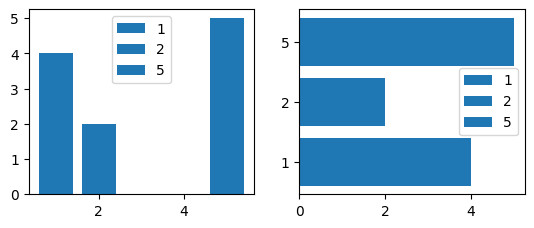

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6.4, 2.4))
# 1. x使用float数组的例子：
plt.subplot(121)
x = [1, 2, 5]
height = [4, 2, 5]
label = ["1", "2", "5"]
plt.bar(x=x, height=height, label=label)
plt.legend()

# 2. x使用字符串数组的例子
plt.subplot(122)
x = ["1", "2", "5"]
height = [4, 2, 5]
plt.barh(y=x, width=height, label=label)

plt.legend()

- 代码说明：
    - 上面例子说明，x使用字符串，等同于刻度标签的作用（刻度标签不等于标签，标签的主要应用就是在图例中显示的标签），在想控制刻度标签的情况下，x使用字符串数组是更好的选择。

- bar其他参数使用例子：
    - 我们使用了
        - 来自函数显示参数：width，bottom，align
        - 来自`**kwargs`参数：color，facecolor，edgecolor，linewidth，tick_label等参数（来自Rectangle对象的属性基本上参数都有，我们就不举例了）

<BarContainer object of 4 artists>

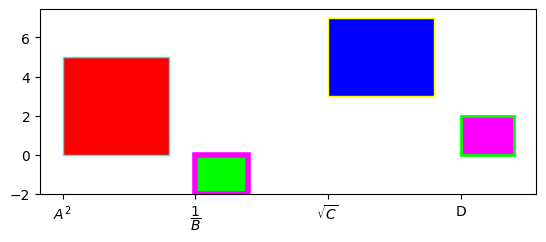

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6.4, 2.4))
# 基本数据
x = ["Sales", "Tech", "Operation", "Administration"]
height = [5, 2, 4, 2]

# 其他可选参数
width=[0.8, 0.4, 0.8, 0.4]
bottom = [0, -2, 3, 0]
align="edge"
color = [(1,0,0), (0, 1, 0), (0, 0, 1), (1, 0, 1)]
edgecolor = [(0, 1, 1), (1, 0, 1), (1, 1, 0), (0, 1, 0)]
linewidth = [1, 4, 1, 2]
tick_label = [r"$A^2$", r"$\dfrac{1}{B}$", r"$\sqrt{C}$", r"D"]   # 替换x的默认刻度标签
plt.bar(x=x, height=height, 
        width=width, bottom=bottom, align=align, 
        color=color, edgecolor=edgecolor, linewidth=linewidth,
        tick_label=tick_label)

- `**kwargs`参数中误差线参数说明（这是一组参数，用来控制误差线的绘制）：
    - xerr, yerr：这两个参数用来在bar条形图上添加误差线，表示数据的不确定性或标准差。xerr表示y方向误差。yerr表示x方向误差，误差数据是数据左右（height +/- error）。参数类型：
        - 一个float值（标量）：所有bar的误差一样。
        - 长度为N的一维数组：长度与x一样并对应每个bar的误差值。
        - 维度为（2，N）的二维数组：分开表示正误差(+)与负误差(-)，第一行表示误差下限，第二行表示误差上限。
        - 为None：表示没有误差线。
    - ecolor：误差线的颜色，参数为一个颜色，或者颜色数组。默认是一个值：`black`（黑色）
    - capsize：设置误差线两端水平短线（帽盖）的长度，用于美化误差线。参数类型是float，缺省值为0.0，可以通过环境参数设置`rcParams["errorbar.capsize"]`
    - error_kw：来组errorbar函数的参数。注意：这里设置的ecolor与capsize参数，要优先于上面两个独立参数。
        - errorbar函数的定义：`Axes.errorbar(x, y, yerr=None, xerr=None, fmt='', *, ecolor=None, elinewidth=None, capsize=None, barsabove=False, lolims=False, uplims=False, xlolims=False, xuplims=False, errorevery=1, capthick=None, data=None, **kwargs)`
        - errorbar的属性参数都可以通过error_kw在bar函数中使用。

- 条形图中误差线的绘制例子：

<BarContainer object of 4 artists>

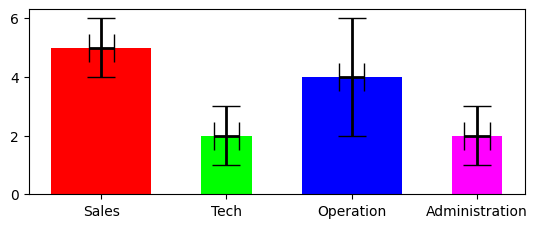

In [54]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6.4, 2.4))
# 基本数据
x = ["Sales", "Tech", "Operation", "Administration"]
height = [5, 2, 4, 2]
# 其他可选参数
width=[0.8, 0.4, 0.8, 0.4]
color = [(1,0,0), (0, 1, 0), (0, 0, 1), (1, 0, 1)]

# 误差线参数
xerr = [0.1, 0.1, 0.1, 0.1]   # x方向误差（在垂直条形图中很少用）
yerr = [1, 1, 2, 1]   # y方向误差

# generator = np.random.default_rng(seed=202510141700)
# ecolor = generator.random(size=(4, 4), dtype=float)  # 生成4个随机颜色（包含透明度）
ecolor = (0, 0, 0, 1)
capsize = 10  # 误差线的帽盖(使用capsize参数，ecolor只能是一个颜色类型，不能是数组)

error_kw = {
    "elinewidth": 2
}

plt.bar(x=x, height=height, width=width, color=color,
        yerr=yerr, xerr=xerr, capsize=capsize, ecolor=ecolor, error_kw=error_kw)

- 代码说明：
    - error_kw中errorbar函数的参数在设置的时候，需要小心，容易重复设置而导致报错。
    - 指定capsize参数的时候，ecolor参数只能使用一个颜色指定所有误差线，不能每个bar的误差线设置不同的颜色，因为会报错。

- bar_label函数的原型定义与参数说明：
    - 该函数主要用来绘制每个bar的标签。
```python
matplotlib.pyplot.bar_label(
    container,   # 标签绘制的容器，以bar与hbar返回的BarContainer对象
    labels=None,  # 每个bar的标签
    *, 
    fmt='%g',  # 标签的格式
    label_type='edge',  # 标签的类型，主要设置标签放置的位置，可以取值{'edge', 'center'}，edge表示标签绘制在bar的边上，ceneter表示绘制在中间。默认是edge
    padding=0, # bar与标签的间距。
    **kwargs)   # 设置来自`Axes.annotate`对象的属性（比如文本属性）
```

- 使用bar_label绘制条形图标签的例子（在上面的例子上面增加bar_label的使用）：

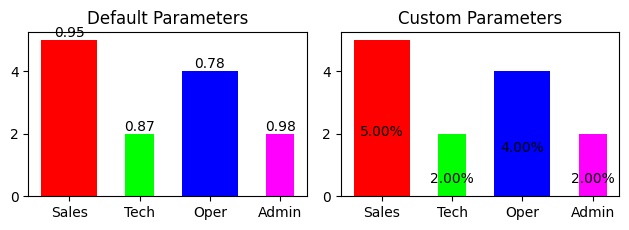

In [81]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6.4, 2.4))
# 基本数据
x = ["Sales", "Tech", "Oper", "Admin"]
height = [5, 2, 4, 2]
# 其他可选参数
width=[0.8, 0.4, 0.8, 0.4]
color = [(1,0,0), (0, 1, 0), (0, 0, 1), (1, 0, 1)]

# --------------------全部采用默认值的情况
plt.subplot(121)
# 记得返回绘制的bar容器
bars= plt.bar(x=x, height=height, width=width, color=color)
# bar_label的使用
labels = [0.95, 0.87, 0.78, 0.98]
plt.bar_label(bars, labels=labels)    # 设置标签
plt.gca().set_title("Default Parameters")

# --------------------采用用户设置的值。
plt.subplot(122)
# 记得返回绘制的bar容器
bars= plt.bar(x=x, height=height, width=width, color=color)
# bar_label的参数使用
fmt = "%4.2f%%"
padding = -10  # 可以调整标签的位置
label_type = 'center'
plt.bar_label(bars, fmt=fmt,padding=padding, label_type= label_type)  # fmt只有在没有设置labels=labels参数的时候有效，格式化的是height参数中的数据。
plt.gca().set_title("Custom Parameters")
plt.tight_layout()

- 代码说明：
    - bar_label函数中labels参数与fmt参数只能二选一使用。如果两个参数同时设置，只有labels产生作用，fmt无效。
    - label_type参数与padding结合可以调整标签的位置。

- 其他条形图绘制：
    - errorbar函数绘制误差条形图。函数原型定义如下（参数与前面bar等函数类似）：
```python
matplotlib.pyplot.errorbar(
    x, y,    # 数据位置
    yerr=None, xerr=None, # x误差线与y误差线 
    fmt='',  # 用来设置数据点（marker）与连线的样式linestyle（见plot函数中的介绍）。
    *, 
    ecolor=None, elinewidth=None, capsize=None, # 误差线的颜色，宽度，帽盖大小
    barsabove=False, # 误差线与marker位置点的关系，barsabove=True表示误差线在下面，marker在上面。
    lolims=False, uplims=False,   # y方向的误差线显示：上误差线与下误差线是否显示， 参数类型是bool值或者bool数组。True表示不显示
    xlolims=False, xuplims=False, # x方向的误差线显示：左误差线与有误差线是否显示，参数类型是bool值或者bool数组。False表示显示
    errorevery=1, 
    capthick=None, # 是来自Line2D属性markeredgewidth的别名。
    data=None, 
    **kwargs)   # 来自Line2D对象的属性
```
函数返回ErrorbarContainer对象。

- errorbar函数使用例子： 

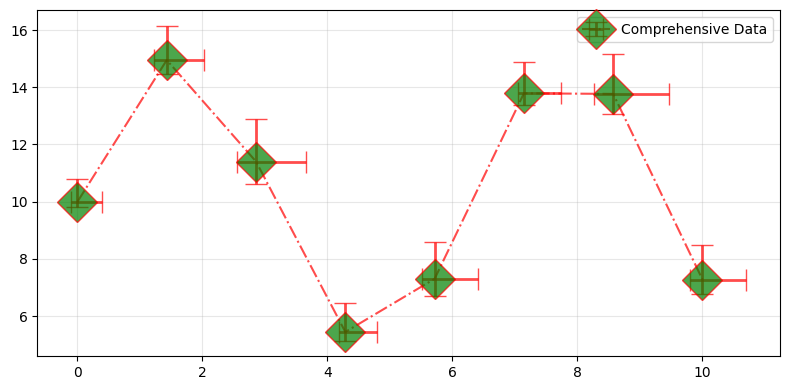

In [102]:
import matplotlib.pyplot as plt
import numpy as np
# 多参数组合使用
plt.figure(figsize=(8, 4.0))

# 创建复杂的数据集
x = np.linspace(0, 10, 8)
y = np.sin(x) * 5 + 10

# 不同类型的误差
y_lower = [0.2, 0.5, 0.8, 0.3, 0.6, 0.4, 0.7, 0.5]  # 下误差
y_upper = [0.8, 1.2, 1.5, 1.0, 1.3, 1.1, 1.4, 1.2]  # 上误差
x_lower = [0.1, 0.2, 0.3, 0.1, 0.2, 0.1, 0.3, 0.2]  # 左误差
x_upper = [0.4, 0.6, 0.8, 0.5, 0.7, 0.6, 0.9, 0.7]  # 右误差

# 组合使用所有参数
plt.errorbar(x, y, 
            yerr=[y_lower, y_upper],
            xerr=[x_lower, x_upper],
            fmt='D-.',  # 菱形标记marker，linestyle
            capsize=8,
            elinewidth=2,
            markersize=20,
            color='red',
            markerfacecolor="green",
            alpha=0.7,
            label='Comprehensive Data')

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

- 代码说明：
    - 这段代码主要演示errorbar函数的绘制效果与数据参数使用xerr与yerr的二维使用方式。
    - fmt设置数据绘制点形状（见scatter函数中点的绘制），以及数据点连线的样式。

- barsabove参数的理解例子

<Figure size 1200x600 with 0 Axes>

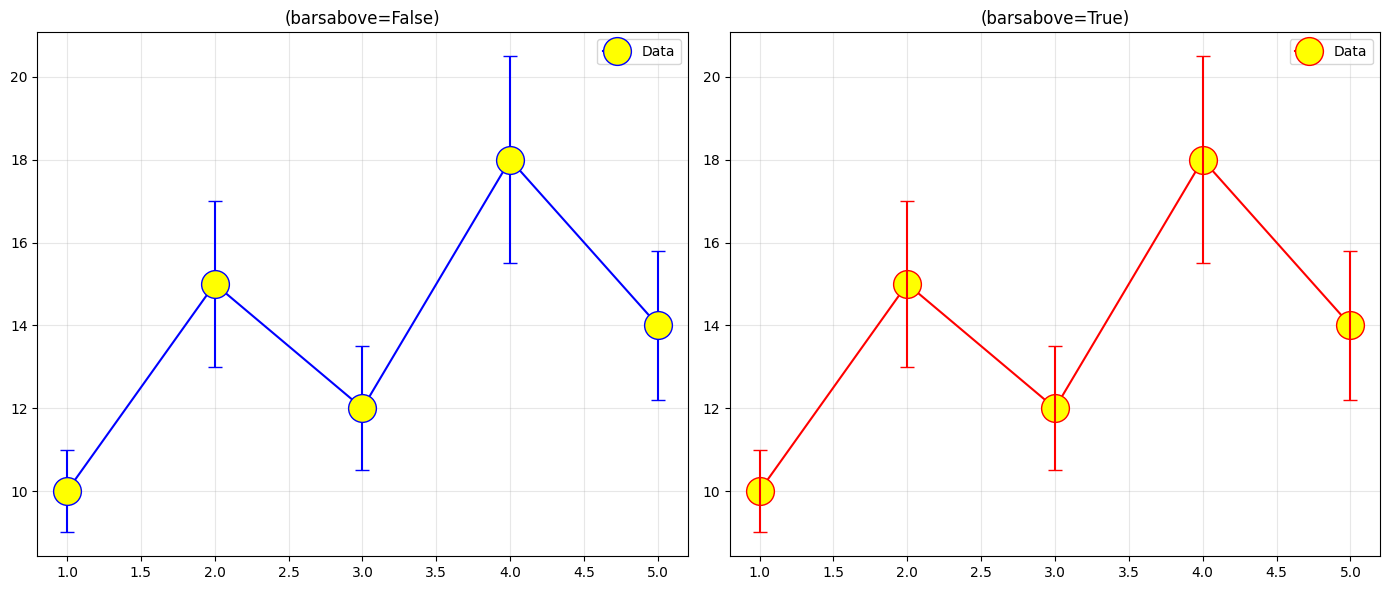

In [104]:
import matplotlib.pyplot as plt
import numpy as np
# barsabove参数控制误差线位置
plt.figure(figsize=(12, 6))

x = np.arange(1, 6)
y = [10, 15, 12, 18, 14]
y_errors = [1, 2, 1.5, 2.5, 1.8]


plt.figure(figsize=(14, 6))

plt.subplot(121)
# 默认误差线在数据点下方
plt.errorbar(x, y, yerr=y_errors, fmt='o-', capsize=5, 
             color='blue', label='Data', markersize=20, markerfacecolor="yellow")
plt.gca().set_title('(barsabove=False)')
plt.grid(True, alpha=0.3)
plt.legend()

# 误差线在数据点上方
plt.subplot(122)
plt.errorbar(x, y, yerr=y_errors, fmt='o-', capsize=5,
             color='red', barsabove=True, label='Data', markersize=20, markerfacecolor="yellow")
plt.gca().set_title('(barsabove=True)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

- 代码说明：
    - 左边的图表的误差线在marker下方，右边的误差线在marker上面。

- 使用lolims, uplims参数控制误差线的显示：

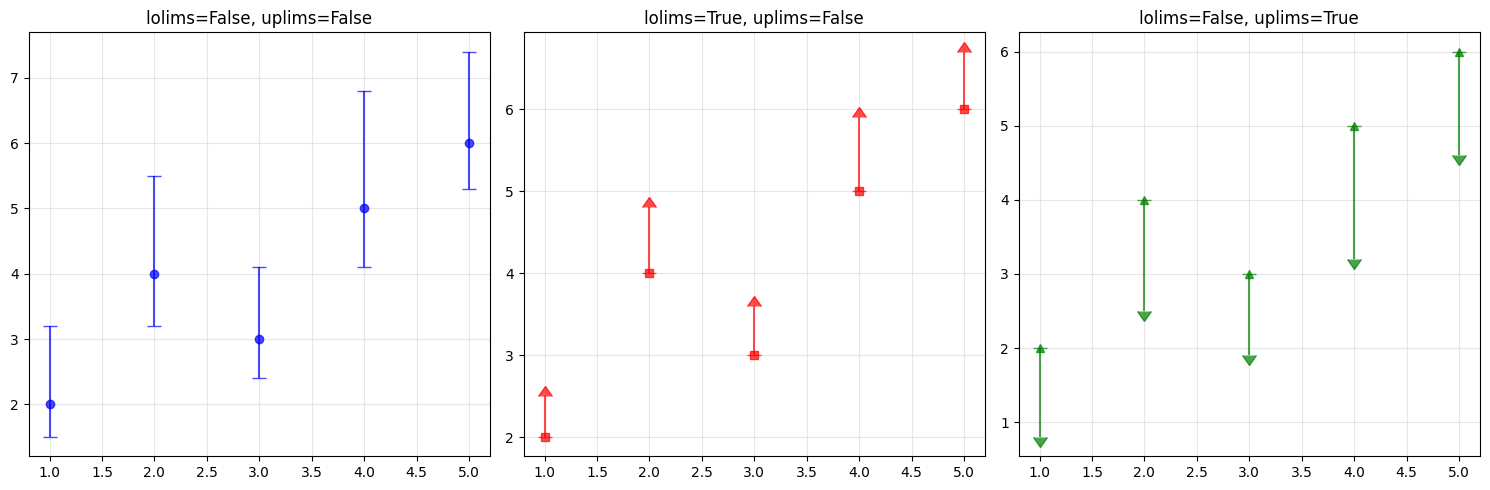

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.arange(1, 6)
y = [2, 4, 3, 5, 6]

# 下误差和上误差
lower_errors = [0.5, 0.8, 0.6, 0.9, 0.7]  # 下误差
upper_errors = [1.2, 1.5, 1.1, 1.8, 1.4]  # 上误差

plt.figure(figsize=(15, 5))

# 传统对称误差线
plt.subplot(131)
plt.errorbar(x, y, yerr=[lower_errors, upper_errors], lolims=False, 
             fmt='o', capsize=5, color='blue')
plt.gca().set_title('lolims=False, uplims=False')
plt.grid(True, alpha=0.3)

# 只显示下误差线 (lolims)
plt.subplot(132)
plt.errorbar(x, y, yerr=lower_errors, lolims=True,
             fmt='s', capsize=5, color='red')
plt.gca().set_title('lolims=True, uplims=False')
plt.grid(True, alpha=0.3)

# 只显示上误差线 (uplims)
plt.subplot(133)
plt.errorbar(x, y, yerr=upper_errors, uplims=True,
             fmt='^', capsize=5, color='green')
plt.gca().set_title('lolims=False, uplims=True')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 值显示上或者下误差下，误差线的端点样式采用的是箭头（caret也称插入符），使用caret表示只显示一部分误差线。

### (6) 其他基础绘制函数

- 其他图形绘制函数包含：
    - step函数：绘制阶梯状图形
    - stem函数：绘制垂直于基线（水平）的线段（茎图）
    - eventplot函数：绘制事件线
    - stackplot函数：绘制堆叠面积图或流图
    - polar函数：绘制极坐标图形
    - broken_barh函数：绘制系列条形图
    - fill，fill_between，fill_betweenx函数：填充绘制，fill填充多边形之间区域，fill_between与fill_betweenx填充曲线之间区域
    - loglog，semilogx，semilogy函数：创建对数坐标系（loglog用来创建x，y都是对数刻度，semilogx创建x轴是对数刻度，semilogy创建y是对数刻度）。

- 使用step绘制阶梯状图形

- step函数的原型定义与参数说民：
```python
- `matplotlib.pyplot.step(
    x, y,  # 折线的位置点
    *args,  # 折线的属性参数：边长参数，主要是fmt参数用来控制折线的端点（marker）与连线样式，以及颜色，这个参数实际上是**kwargs参数的快捷参数。使用位置参数。
    where='pre',  # 用来设置阶梯开始位置：取值{'pre', 'post', 'mid'}，默认值是pre
    data=None, 
    **kwargs)` # 来自plot函数中的属性参数设置。
```

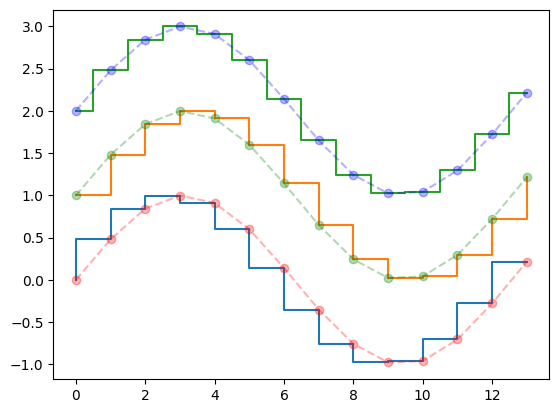

In [115]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(14)
y = np.sin(x / 2)

# where参数取值pre
plt.step(x, y, where="pre")
plt.plot(x, y, 'o--', color='red', alpha=0.3)

# where参数取值post
plt.step(x, y+1, where="post")
plt.plot(x, y+1, 'o--', color='green', alpha=0.3)

# where参数取值mid 
plt.step(x, y+2,  where="mid")
plt.plot(x, y+2, 'o--', color='blue', alpha=0.3)

plt.show()

- 代码说明：
    - where的理解就是，两个点之间的折线折的位置：
        - pre：从第一个点先垂直梯度，然后水平线到第二个点。
        - mid：先从第一个点水平线到两个点的水平中间点，然后垂直梯度，最后水平线到第二个点。
        - post： 先从第一个点水平线到第二点的垂直位置，然后梯度到第二个点。

- 使用stem函数绘制茎干图

- stem函数的原型定义与说明：

```python
matplotlib.pyplot.stem(
    *args,   # 两个位置参数：locs指定茎干线段的位置，heads指定茎干线段的长度
    linefmt=None,    # 茎干线段的格式：颜色与样式，样式支持："-", "--","-.",":"
    markerfmt=None,  # 设置茎干上端点的marker形状，包括颜色
    basefmt=None,   # 基线格式：默认是"C3-"，`C3`是默认循环颜色的第三个，`-`是实线
    bottom=0,   # 基线位置
    label=None,  # 标签
    orientation='vertical',   # 基线方向，取值{'vertical', 'horizontal'},默认值vertical。
    data=None)
```

返回值StemContainer：marker（端点），lines（茎干线）， lines（基线）

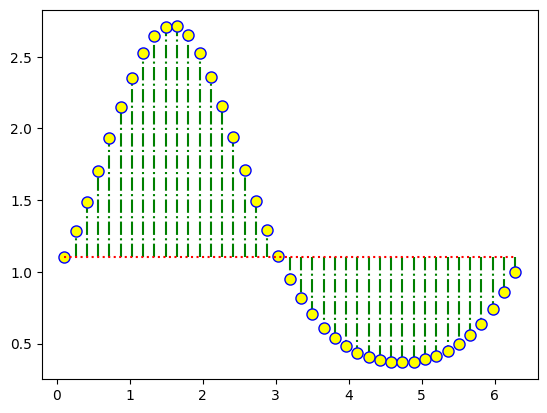

In [124]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0.1, 2 * np.pi, 41)
y = np.exp(np.sin(x))

markerline, stemlines, baseline = plt.stem(
    x, y, 
    linefmt='g-.', 
    markerfmt='.b', 
    basefmt=":r", 
    bottom=1.1)
markerline.set_markerfacecolor('yellow')
markerline.set_markersize(16)  # 16平方点
plt.show()

- 代码说明：
    - `markerline.set_markerfacecolor('yellow')`代码利用返回的marker对象来设置marker的颜色。

- 使用eventplot函数绘制平行线
    - 该函数主要用来表达时间发生，比如地震事件，时间分布，脉冲数据等。

- eventplot函数的原型定义与说明：

```python
matplotlib.pyplot.eventplot(
    positions,  # 设置事件系列，参数类型是数组或者数组的数组（不是二维数组，因为数组中的数组长度可以不同），事件组可以使用 lineoffsets, linelengths, linewidths, colors and linestyles等参数设置样式。
    *, 
    orientation='horizontal',   # 事件组的方向，取值{'horizontal', 'vertical'}，默认horizontal
    lineoffsets=1,  # 参数是float类型或者数组，直线中心到原点的偏离距离。默认值是1.
    linelengths=1,  # 参数是float类型或者数组，是线段的总长度，时间线段从lineoffset - linelength/2 到 lineoffset + linelength/2)伸展（以偏离点，上下各一半linelengths），默认值1
    linewidths=None,  # 参数是float类型或者数组，事件线的宽度，单位是points。
    colors=None,  # 事件线的颜色
    alpha=None,  # 事件线的透明度
    linestyles='solid',  # 事件线的样式, 参数类型可以是一个样式，也可以每个事件对应一个样式
    data=None, 
    **kwargs) # 来自LineCollection对象的属性。
```

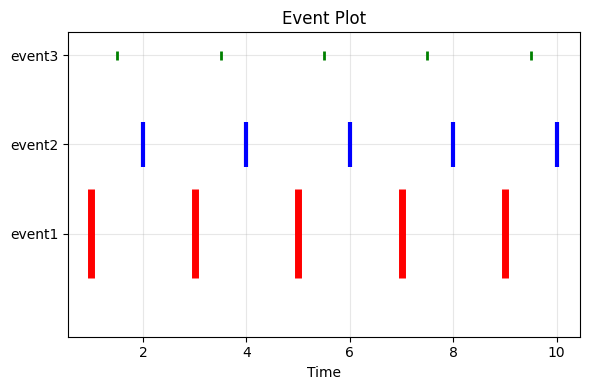

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# 基本示例
plt.figure(figsize=(6, 4))

# 创建事件数据
events1 = [1, 3, 5, 7, 9]  # 第一组事件
events2 = [2, 4, 6, 8, 10] # 第二组事件
events3 = [1.5, 3.5, 5.5, 7.5, 9.5] # 第三组事件

# 绘制事件图
plt.eventplot([events1, events2, events3], 
              colors=['red', 'blue', 'green'],
              lineoffsets=[1, 2, 3],
              linelengths=[1, 0.5, 0.1],
              linewidths=[5, 3, 2]
             )

plt.yticks([1, 2, 3], ['event1', 'event2', 'event3'])
plt.xlabel('Time')
plt.title('Event Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- 代码说明：
    - lineoffsets参数设置每个事件序列在Y方向的偏离距离。
    - linelengths参数设置每个事件序列的线段绘制长度。
    - linewidths参数设置每个事件序列的线段绘制宽度。
- 这个代码仅仅是说明绘制效果，在实际应用中通过线段之间稠密用来可视化一些紧急事件，脉冲频率。

- 使用stackplot函数绘制堆叠面积图
    - 适合显示多个数据序列的累积效果，比如：预算分配可视化、资源使用情况、市场份额变化、收入来源分析等。

- stackplot函数的原型定义与说明：

```python
matplotlib.pyplot.stackplot(
    x,  # 形状为（N,）的数组，x方向位置
    *args, # 堆叠数据：（M，N）的二维数组，可以使用变长参数，用M个(N，)设置
    labels=(),  # 对应堆叠数据的标签。成都对应上面的M。类型是字符串列表。
    colors=None,  # 设置颜色，多个颜色。类型是颜色列表。
    hatch=None, # 设置区域图案，类型是字符串列表。
    baseline='zero',  # 设置堆叠图的基线，取值{'zero'（零基线）, 'sym'（对称基线）, 'wiggle'（摆动基线）, 'weighted_wiggle'（加权摆动基线）}
    data=None, 
    **kwargs
)
```

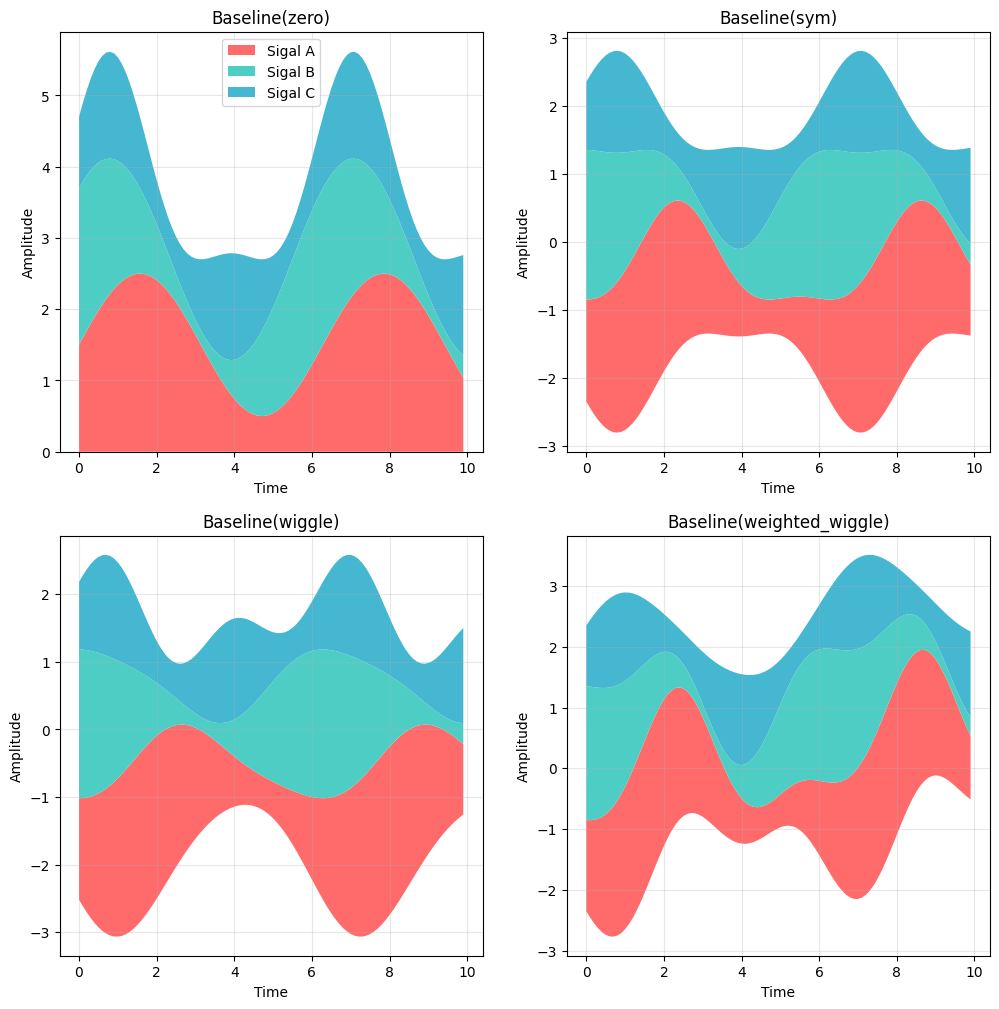

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# 零基线示例
plt.figure(figsize=(12, 12))

x = np.arange(0, 10, 0.1)
y1 = np.sin(x) + 1.5
y2 = np.cos(x) + 1.2
y3 = 0.5 * np.sin(2*x) + 1.0

# zero基线
plt.subplot(221)
plt.stackplot(x, y1, y2, y3,
              labels=['Sigal A', 'Sigal B', 'Sigal C'],
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              baseline='zero')

plt.title('Baseline(zero)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# sym基线
plt.subplot(222)
plt.stackplot(x, y1, y2, y3,
              labels=['Sigal A', 'Sigal B', 'Sigal C'],
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              baseline='sym')

plt.title('Baseline(sym)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# wiggle基线
plt.subplot(223)
plt.stackplot(x, y1, y2, y3,
              labels=['Sigal A', 'Sigal B', 'Sigal C'],
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              baseline='wiggle')

plt.title('Baseline(wiggle)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# weighted_wiggle基线
plt.subplot(224)
plt.stackplot(x, y1, y2, y3,
              labels=['Sigal A', 'Sigal B', 'Sigal C'],
              colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              baseline='weighted_wiggle')

plt.title('Baseline(weighted_wiggle)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout
plt.show()

- 代码说明：
    - 零基线：从y=0开始堆叠，显示每个时间点的总累积值，最适合显示总量变化
        - 适合：显示总量累积
    - 对称基线：基线在中间，上下对称，适合显示相对于中心线的正负偏差，常用于显示波动、偏差数据
        - 适合：有正有负的数据
    - 摆动基线：最小化堆叠区域边界的总斜率（斜率左边坡度为负数，右边斜率为正数，总斜率最小，设置为0，产生左右摆动），产生"摆动"效果，使图表更紧凑。
        - 适合：比较多个序列的相对变化
    - 加权摆动基线：考虑数据序列的权重，大振幅数据对基线形状影响更大，比标准wiggle更平滑。
        - 适合：数据幅度差异大时

- 使用polar函数绘制极坐标图形
    - 适合绘制雷达图。

- polar函数的原型定义与说明：

```python
matplotlib.pyplot.polar(
    *args,  # theta: 角度，r：极值，fmt格式。
    **kwargs)
```

找个函数实际是plot函数的封装，所有参数都会传递给pyplot.plot函数。更加简洁，属于专门极坐标绘制。

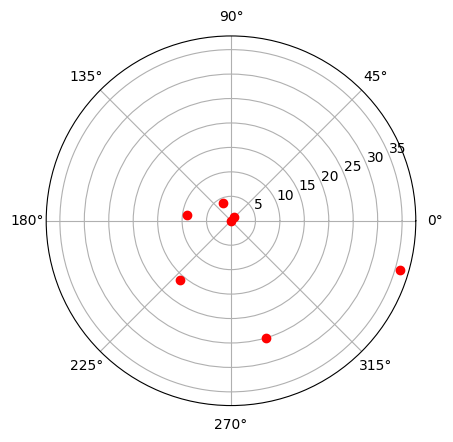

In [16]:
import matplotlib.pyplot as plt
import numpy as np
# 二次曲线
x = np.arange(7)
y = xs**2
plt.polar(x, y, 'ro')


- 代码说明：
    - polar函数自动创建坐标系，而且是极坐标系。

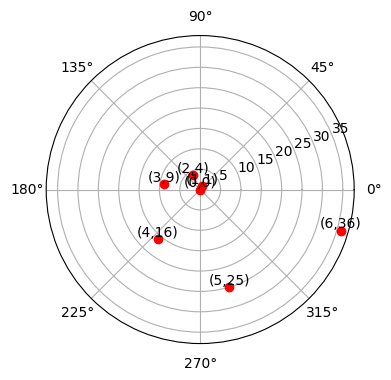

In [15]:
import matplotlib.pyplot as plt
import numpy as np
# 二次曲线
x = np.arange(7)
y = xs**2

plt.figure(figsize=(10, 4))
for x_, y_ in zip(x, y):
    plt.polar(x_, y_, 'ro')
    plt.text(x_, y_, F"({int(x_):d},{int(y_):d})", horizontalalignment='center', verticalalignment='bottom')

- 代码说明
    - 我们为了标注雷达点，使用polar函数逐点绘制，并且还提前使用text函数进行标注。

- 使用broken_barh绘制系列条形图
    - broken_barh专门用于绘制水平方向的间断条形图。它特别适合表示时间线上的任务、事件或时间段（比如制定计划的甘特图等），尤其当这些时间段不是连续的时候。

- broken_barh函数的原型定义与说明：

```python
matplotlib.pyplot.broken_barh(
    xranges,  # 元组列表（就是列表中的元素都是值对：[(vale1，value2), ...]）, 值对表示(xmin, xwidth)就是x位置与宽度
    yrange,   # 元组，元组中元素表示(ymin, yheight),就是y位置与宽度
    *, 
    data=None,  # 结构化数据（含字段或者KEY，可以下标索引）
    **kwargs)   # 设置来自PolyCollection对象的属性
```

函数返回PolyCollection对象

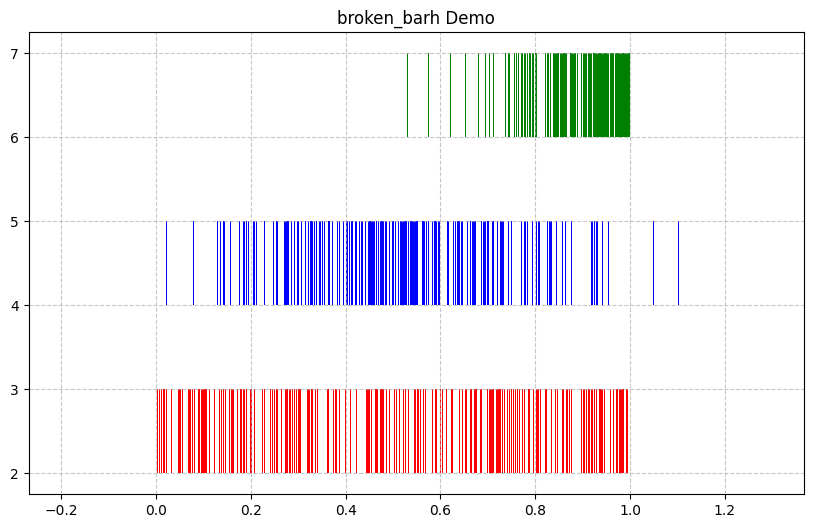

In [49]:
import matplotlib.pyplot as plt
import numpy as np
generator = np.random.default_rng(20251016)

# 创建图形
fig, ax = plt.subplots(figsize=(10, 6))

# 定义条形数据
# 每个元组表示(起始位置, 长度)
x1 = generator.uniform(0, 1, 500)  # 均匀分布
w1= np.ones(shape=(500, )) * 0.001
xranges1 = list(zip(x1, w1))
yranges1 = (2, 1) # (起始y位置, 高度)

x2 = generator.normal(0.5, 0.2, 500)  # 正态分布
w2 = np.ones(shape=(500, ))*0.001
xranges2 = list(zip(x2, w2))
yranges2 = (4, 1) # (起始y位置, 高度)

x3 = generator.power(10, 500)   # 指数分布
w3 = np.ones(shape=(500, )) * 0.001
xranges3 = list(zip(x3, w3))
yranges3 = (6, 1) # (起始y位置, 高度)

# 绘制间断条形图
plt.broken_barh(xranges1, yrange1, facecolors='r')
plt.broken_barh(xranges2, yrange2, facecolors='b')
plt.broken_barh(xranges3, yrange3, facecolors='g')
# 添加网格
ax.grid(True, linestyle='--', alpha=0.7)
plt.title('broken_barh Demo')
plt.show()

- 代码说明：
    - `x1 = generator.uniform(0, 1, 500) ` 代码生成每个间断bar的位置。
    - `w1= np.ones(shape=(500, )) * 0.001` 代码生成每个间断bar的宽度
    - `xranges1 = list(zip(x1, w1))` 代码把两个一维向量，合并成元组对向量，并把向量转换为元组对列表。

- 使用fill，fill_between，fill_betweenx进行填充绘制

- fill，fill_between，fill_betweenx三个函数的原型定义与说明

```python
matplotlib.pyplot.fill(
    *args,  # 这种参数意味着数据可以是多组，每组数据分成三个（x, y, color），颜色可选，x，y用来描述多边形的顶点，color用来描述顶点颜色
    data=None, # 结构化数据，这样x，y，color可以使用结构化数据中的字段或者key。
    **kwargs)   # 设置来自多边形Polygon对象的属性, 包括marker与line
```
fill函数返回Polygon对象

```python
matplotlib.pyplot.fill_between(
    x,    # 曲线的x坐标，参数类型是数组
    y1,   # 第一条曲线的y坐标（x坐标是x，两条曲线共享x坐标）
    y2=0, # 第二条曲线的y坐标
    where=None,  # 定义需要填充的区域。满足x[where]的区域被填充。函数的填充是在x[i]与x[i+1]之间完成，而且必须满足where[i]与where[i+1]都是True的情况。单独一个True的x是不会被填充的。where参数的类型是一个bool数组，与x数组对应，以此来设置是否填充。
    interpolate=False,  # 找个参数在使用where参数才有效。而且在两个曲线交叉时才会被使用。因为where通常用于y1>y2或者类似情况，交叉点不满足会导致不会被填充，interpolate设置为True，函数会自动计算交叉点，并把填充区域延伸到交叉点。
    step=None, # 如果曲线是阶梯函数（step函数），则使用该参数，用来了解step在哪儿发生，以便正确填充，保持与step曲线的绘制方式一致。
    *, 
    data=None, 
    **kwargs)  # 设置来自FillBetweenPolyCollection对象的属性。也是函数创建的图形对象。
```
函数返回FillBetweenPolyCollection对象。

```python
matplotlib.pyplot.fill_betweenx(
    y, 
    x1, 
    x2=0, 
    where=None, 
    step=None, 
    interpolate=False, 
    *, 
    data=None, 
    **kwargs)
```
fill_betweenx与fill_between函数类似，一个是填充垂直方向，一个填充水平方向。

- fill函数应用例子

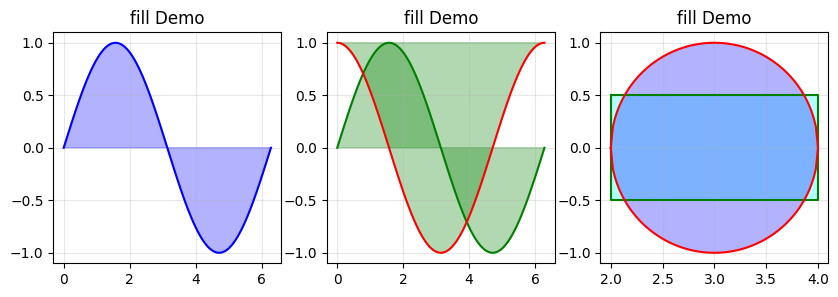

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据
x = np.linspace(0, np.pi * 2, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# 创建图形
plt.figure(figsize=(10, 3))

# 填充曲线下方的区域
plt.subplot(131)
plt.plot(x, y1,color="blue")
plt.fill(x, y1, alpha=0.3, color='blue')   # y2==0
plt.title('fill Demo')
plt.grid(True, alpha=0.3)

# 填充个两个曲线之间的区域
plt.subplot(132)
plt.plot(x, y1,color="green")
plt.plot(x, y2,color="red")
plt.fill(x, y1, x, y2, alpha=0.3, color='green') 
plt.title('fill Demo')
plt.grid(True, alpha=0.3)

# 多边形的情况
# 填充个两个曲线之间的区域
plt.subplot(133)
px1 = [2,     4,    4,    2,  2]   # 4边形
py1 = [0.5, 0.5, -0.5, -0.5,  0.5]

px2 = np.linspace(2, 4, 100, dtype=float)    # 圆(x-3) + y2 = 1
py2 = np.sqrt(1.0 - (px2-3) * (px2-3))

plt.plot(px1, py1,color="green")

plt.plot(px2, py2,color="red")   
plt.plot(px2, -py2,color="red")

plt.fill(px1, py1, "cyan", px2, py2, "blue", px2, -py2, "blue", alpha=0.3) 
plt.title('fill Demo')
plt.grid(True, alpha=0.3)


plt.show()

- 代码说明：
    - 第一例子说明了`*args`参数只有一组数据的情况，第二个例子说明了`*args`参数有两组数据的情况，第三个例子说明的在`*args`参数中使用color的情况。
    - 注意：使用关键字color参数与在`*args`中使用颜色值的情况下，关键字color参数优先。
    - `plt.plot(px2, py2,color="red") `绘制上半圆
    - `plt.plot(px2, -py2,color="red")`绘制下半圆 

- fill_between与fill_betweenx函数使用例子
    - 我们使用圆的绘制来举例子

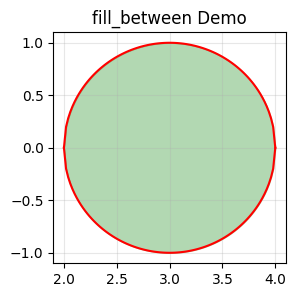

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据
x = np.linspace(0, np.pi * 2, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# 创建图形
plt.figure(figsize=(3, 3))



# 多边形的情况
# 填充个两个曲线之间的区域
x  = np.linspace(2, 4, 100, dtype=float)    # 圆(x-3) + y2 = 1
y1 =  np.sqrt(1.0 - (px2-3) * (px2-3))
y2 = -np.sqrt(1.0 - (px2-3) * (px2-3))

plt.plot(x, y1,color="red")   
plt.plot(x, y2,color="red")

plt.fill_between(x, y1, y2, color="green", alpha=0.3) 
plt.title('fill_between Demo')
plt.grid(True, alpha=0.3)


plt.show()

- 代码说明
    - 在某些情况下，fill_between比fill更加方便。

- fill_between函数中where参数与interpolate参数的使用

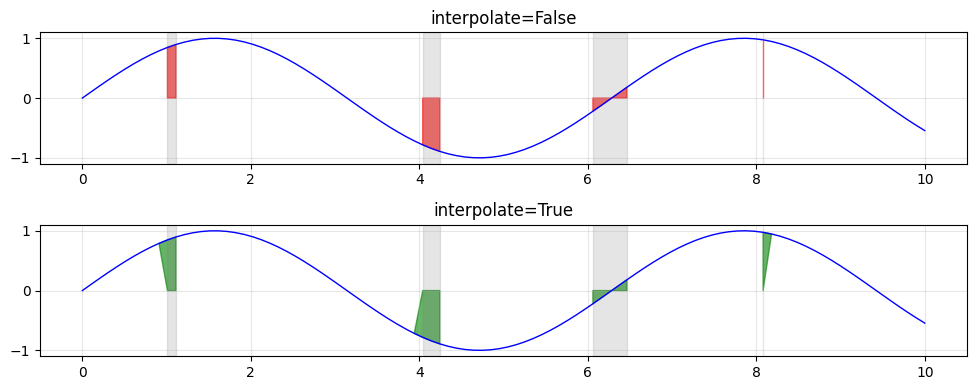

In [112]:
import matplotlib.pyplot as plt
import numpy as np

# 创建包含孤立 True 区域的数据
x = np.linspace(0, 10, 100)
y = np.sin(x)

# 创建不连续的 where 条件
# condition = (x > 2) & (x < 3) | (x > 5) & (x < 5.5) | (x > 8) & (x < 8.2)
condition = np.zeros_like(x, dtype=bool)
condition[10:12] = True    # 2个点
condition[40:43] = True    # 3个点  
condition[60:65] = True    # 5个点
condition[80:81] = True    # 1个点

plt.figure(figsize=(10, 4))

# 子图1: interpolate=False (默认)
plt.subplot(211)
plt.plot(x, y, 'b-', linewidth=1, label='sin(x)')
plt.fill_between(x, y, 0, 
                 where=condition,
                 interpolate=False,  # 默认值
                 alpha=0.6, color='red')
# 为了直观绘制满足条件的填充区
for start, end in [(10,12), (40,43), (60,65), (80,81)]:
    plt.axvspan(x[start], x[end-1], alpha=0.2, color='gray')
plt.title('interpolate=False')
plt.grid(True, alpha=0.3)

# 子图2: interpolate=True
plt.subplot(212)
plt.plot(x, y, 'b-', linewidth=1, label='sin(x)')
plt.fill_between(x, y, 0, 
                 where=condition,
                 interpolate=True,  # 启用插值
                 alpha=0.6, color='green')
for start, end in [(10,12), (40,43), (60,65), (80,81)]:
    plt.axvspan(x[start], x[end-1], alpha=0.2, color='gray')
plt.title('interpolate=True')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在代码中提前使用axvspan函数，用来显示满足where的区域。通过这个区域，我们直观看见interpolate=True的时候，在边界处进行平滑处理。
    - 我们在代码中故意设置figure的尺寸为(10, 4),可以视觉上放大平滑处理的效果(就是插值处理)

- 使用loglog函数创建对数坐标

- loglog、semilogx，semilog函数原型定义与说明

```python
matplotlib.pyplot.loglog(
    *args,  # 指定数据x, y, fmt，fmt可选，该参数说明可以同时绘制多条曲线
    **kwargs)   # 来自plot的所有参数。
```

semilogx函数
`matplotlib.pyplot.semilogx(*args, **kwargs)`

semilogy函数
`matplotlib.pyplot.semilogy(*args, **kwargs)`

- loglog函数实际就是plot函数的封装，参数与plot一致，这里不赘述。但是有三个参数是与计算对数有关，可以设置：
    - base对数的基。
    - subs设置短刻度。
    - nonpositive设置对负数的处理{'mask', 'clip'}：mask表示屏蔽，clip表示转换为非常小的正数。

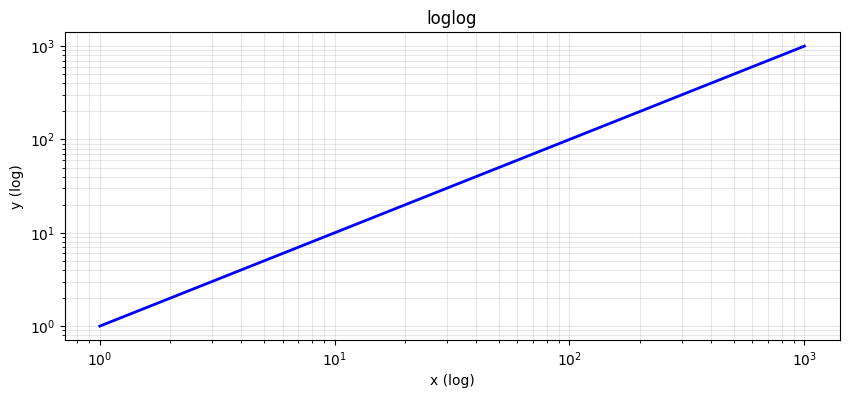

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据 - 幂律关系
x = np.logspace(0, 3, 100)  # 从10^0到10^3 
y = x  
subs=[2,3,4,5,6,7,8,9]

plt.figure(figsize=(10, 4))
plt.loglog(x, y, 'b-', linewidth=2, base=10, subs=[1,2,3,4,5,6,7,8,9], nonpositive="mask")
plt.xlabel('x (log)')
plt.ylabel('y (log)')
plt.title('loglog')
plt.grid(True, which='both', alpha=0.3)
plt.show()

- 代码说明：
    - `x = np.logspace(0, 3, 100)` 代码先生成(0,3)之间100个均匀的数组，然后用这100个数，做10为底的指数运算得到的数组就是最终输出的结果
    - loglog函数等同于对x计算对数，得到的结果实际是(0, 3)之间的均匀数据，就是一条直线。

## 3.2. 分隔线与块

### (1) 分隔线绘制-axline，axvline，axhline

- axline，axvline，axhline函数原型定义与参数说明：
    - `matplotlib.pyplot.axline(xy1, xy2=None, *, slope=None, **kwargs)`
        - 绘制一条无限长直线，可以设置下面参数：
            - xy1, xy2：由xy1,xy2决定的直线（直线经过xy1与xy2），类型是float元组(float, float)
            - `*`:这个符号以后得参数必须使用关键字参数。
            - slope：这个参数只有在xy2没有指定的情况下使用，slope设置斜率，直线由xy1与slope决定，slope参数类型是float。
            - `**kwargs`：设置来自Line2D对象的属性。
        - 函数返回的是Line2D对象。 
    - `matplotlib.pyplot.axvline(x=0, ymin=0, ymax=1, **kwargs)`
        - 绘制一条垂直线段，可以设置下面参数：
            - x：垂直线段的x轴位置，类型是float。
            - ymin，ymax：水平线段的开始位置ymin与结束位置ymax，类型是float，ymin默认是0，ymax默认是1。这两个参数取值只能在0-1之间。这两个值使用的是百分比单位。（采用的是标准坐标系的x，y轴是单位向量）
            - `**kwargs`：设置来自Line2D对象的属性。
        - 函数返回Line2D对象。 
    - `matplotlib.pyplot.axhline(y=0, xmin=0, xmax=1, **kwargs)`
        - 绘制一条水平线段，可以设置下面参数：
            - y：水平线段的y轴位置，类型是float。
            - xmin，xmax：水平线段的开始位置xmin与结束位置xmax，类型是float，xmin默认是0，xmax默认是1。这两个参数取值只能在0-1之间。这两个值使用的是百分比单位。（采用的是标准坐标系的x，y轴是单位向量）
            - `**kwargs`：设置来自Line2D对象的属性。
        - 函数返回Line2D对象。 

- axline函数绘制直线的例子：

(-1.0, 3.0)

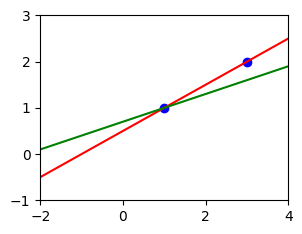

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 参数定义
xy1 = (1.0, 1.0)
xy2 = (3.0, 2.0)
slope = 0.3

plt.figure(figsize=(3.2, 2.4))
plt.axline(xy1, xy2, color="red")
plt.axline(xy1, slope=slope, color="green")
plt.scatter(xy1[0], xy1[1], color="blue")
plt.scatter(xy2[0], xy2[1], color="blue")

# 为了更好体验，通过设置x, y轴的大小，调整线条的位置
plt.xlim(-2, 4)
plt.ylim(-1, 3)


- 代码说明：
    - `plt.xlim(-2, 4)`调整了x轴的大小，可以从x刻度体现出来。
    - 为了体现效果，我们使用scatter函数绘制了xy1，xy2两个点：`plt.scatter(xy1[0], xy1[1], color="blue")`与`plt.scatter(xy2[0], xy2[1], color="blue")`

- 使用axhline与axvline绘制水平与处置线段的例子

(-1.5, 1.5)

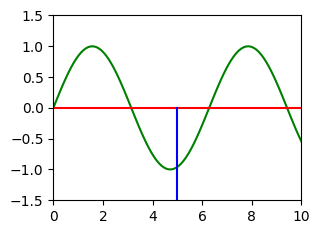

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 参数定义
y = 0   # 采用用户数据单位
xmin = 0   # 采用的是标准坐标系，与坐标刻度无关，取值在0-1之间，
xmax = 1   

x = 5    # 采用用户数据单位
ymin = 0  # 采用的是标准坐标系，与坐标刻度无关，取值在0-1之间，
ymax = 0.5

# 数据线
x_data = np.linspace(0, 10, 100)
y_data = np.sin(x_data)

plt.figure(figsize=(3.2, 2.4))
plt.plot(x_data, y_data, color="green")
plt.axhline(y=y, xmin=xmin, xmax=xmax, color="red")
plt.axvline(x=x, ymin=ymin, ymax=ymax, color="blue")

plt.xlim(0, 10)
plt.ylim(-1.5, 1.5)



- 代码说明：
    - xmin, xmax, ymin, ymax参数取值只能是0-1之间的值，表示的是在坐标系中的百分比。
    - x与y值采用的是用户坐标系，数据与用户数据采用相同单位。
        - `x = 5`, `ymin = 0`,`ymax = 0.5`表示在水平方向，x=5的位置绘制线段，线段处置方向从x坐标系轴开始，到整个坐标系的一半（50%）。
    - axhline与axvline函数绘制的线段，可以用来标识数据，回归线，分类线等，

### (2) 分隔块绘制-axhspan，axvspan

- axhspan与axvspan函数负责绘制矩形块。axhspan负责绘制水平方向矩形块，axvspan负责绘制垂直方向的矩形块。
- axvspan与axhspan函数是Axes对象的axvspan，axhspan函数的封装。

-  axhspan与axvspan函数的原型定义与参数说明：
    - `matplotlib.pyplot.axvspan(xmin, xmax, ymin=0, ymax=1, **kwargs)`
        - 参数说明：
            - xmin，xmax：设置垂直矩形块的位置与宽度，采用的用户数据单位。
            - ymin，ymax：设置垂直矩形块的长度，取值在0-1之间，采用的是坐标系单位。
            - `**kwargs`：设置来自Rectangle对象的属性值。
        - 函数返回Line2D对象。
    - `matplotlib.pyplot.axhspan(ymin, ymax, xmin=0, xmax=1, **kwargs)`
        - 参数说明：
            - ymin，ymax：设置水平矩形块的位置与宽度，采用的用户数据单位。
            - xmin，xmax：设置水平矩形块的长度，取值在0-1之间，采用的是坐标系单位。
            - `**kwargs`：设置来自Rectangle对象的属性值。
        - 函数返回Line2D对象。

- axvspan函数的使用例子 - 用来标识关注数据区域

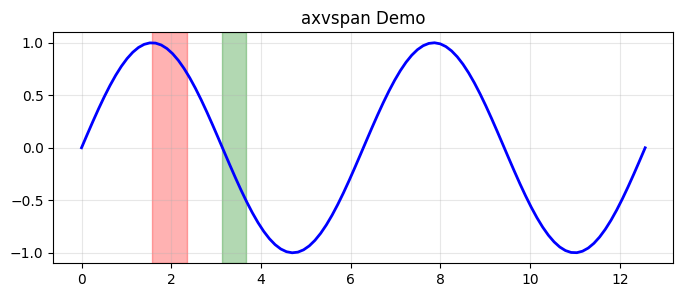

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.linspace(0, np.pi * 4, 100)  # 2个圆周周期
y = np.sin(x)

plt.figure(figsize=(8, 3))
# 用户数据
plt.plot(x, y, 'b-', linewidth=2, label='sin(x)')

# 标注数据区域
plt.axvspan(xmin=np.pi/2, xmax=np.pi/2+np.pi/4, alpha=0.3, color='r')  # 45°区域
plt.axvspan(xmin=np.pi,   xmax=np.pi+np.pi/6 ,  alpha=0.3, color='g')  # 30°度区域

plt.title('axvspan Demo')
plt.grid(True, alpha=0.3)
plt.show()

- 代码说明：
    - 在matplotlib的函数声明中，参数定义形式是`*args`的一定是位置参数，这个时候不能使用关键字参数。
    - 在matplotlib的函数声明中，参数定义形式是`*kwargs`的一定是关键字参数，这个时候不能使用位置参数。
    - 在matplotlib的函数声明中，参数定义形式是`参数名`，这种参数在`*`前可以是位置或者关键字参数，在参数`*`后一定使用关键字参数。
    - 注意axvspan函数的xmin,xmax使用的是用户单位，ymin,ymax使用的是坐标系单位。

-------